<a href="https://colab.research.google.com/github/hwangho-kim/Transformer_Fewshot_PdM/blob/main/Production_FDC_Pipeline_260326_Refactoring_R01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[System] Using device: cuda
-> [Optimize] CUDA AMP (Automatic Mixed Precision) & cuDNN Benchmark Enabled.

Phase 1: Loading data, Aligning & Injecting Scenarios...


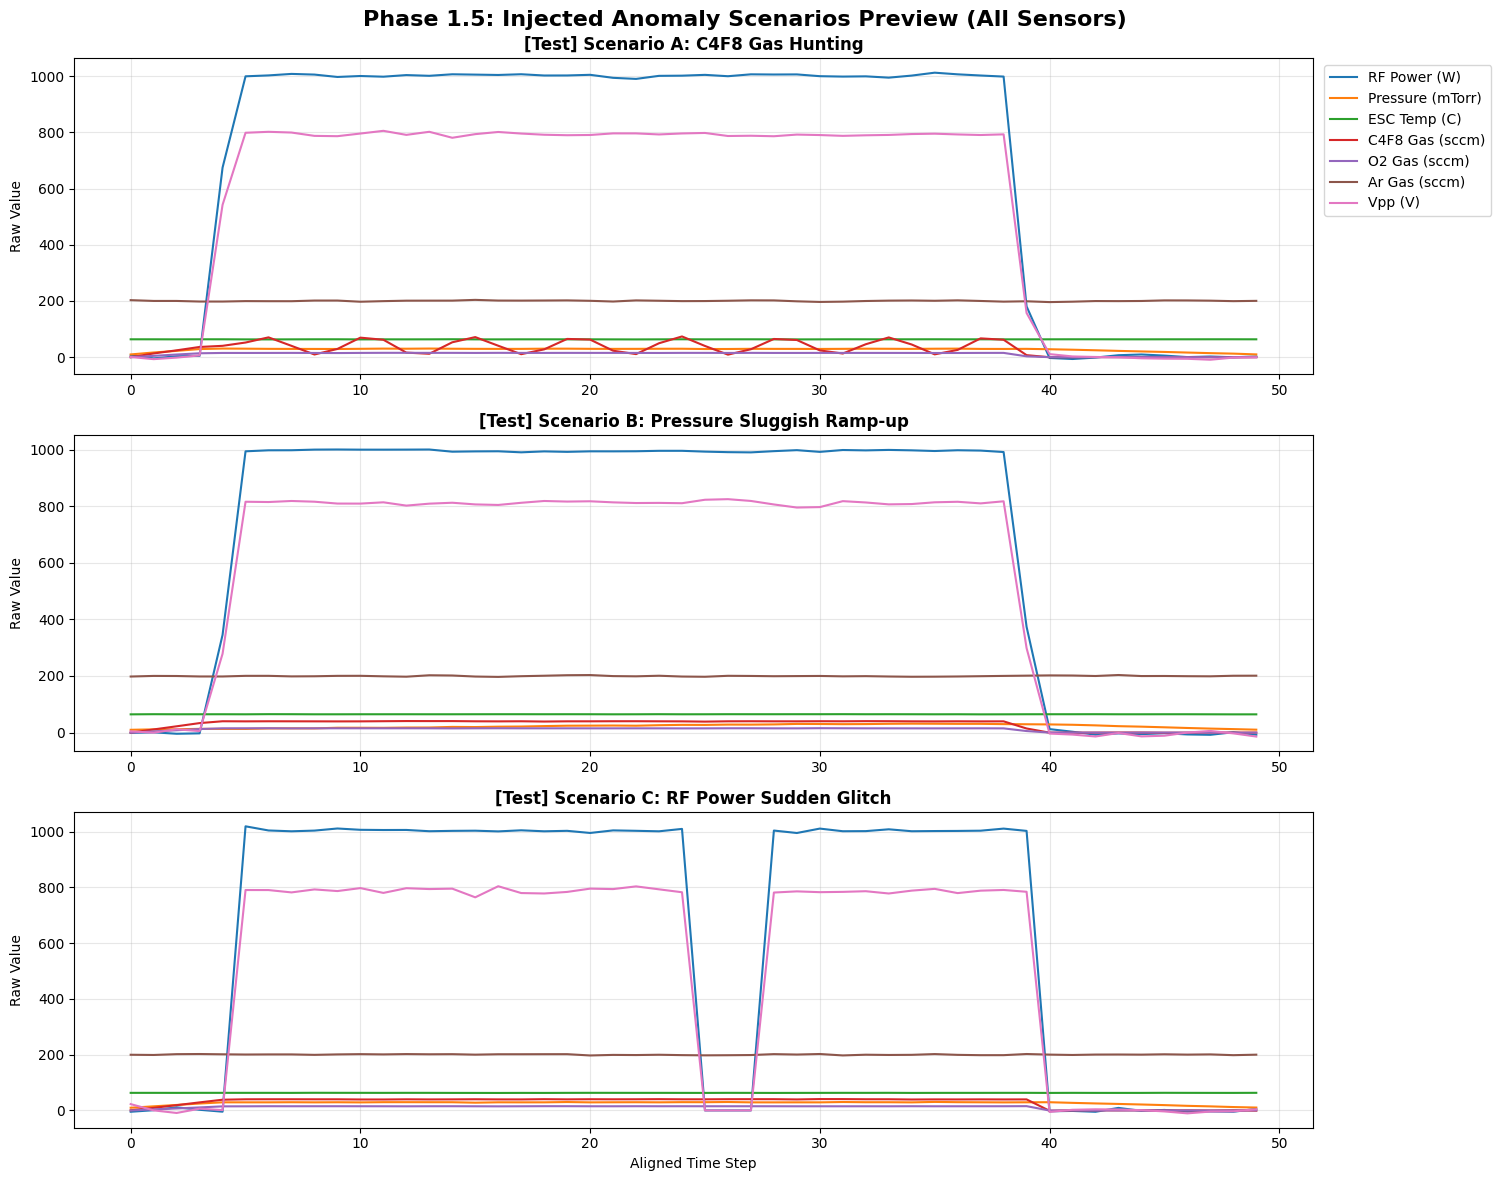

Phase 2: Loading pre-trained model...


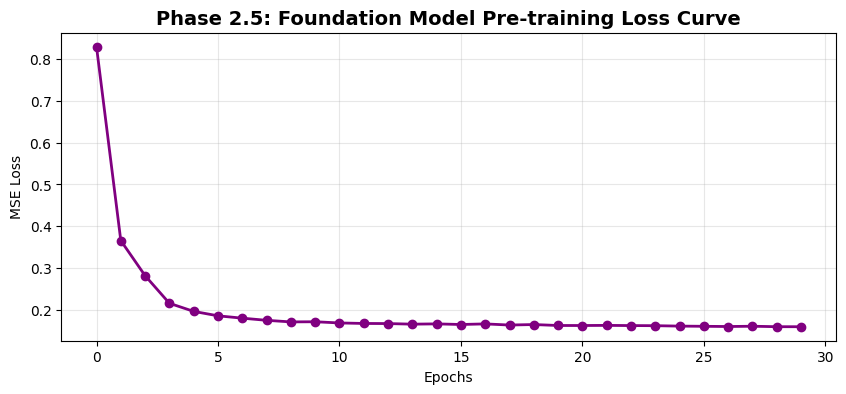

Phase 3: Fine-tuning Diagnostic Head...
   Few-shot Epoch [50/100], Loss: 0.1635
   Few-shot Epoch [100/100], Loss: 0.0700


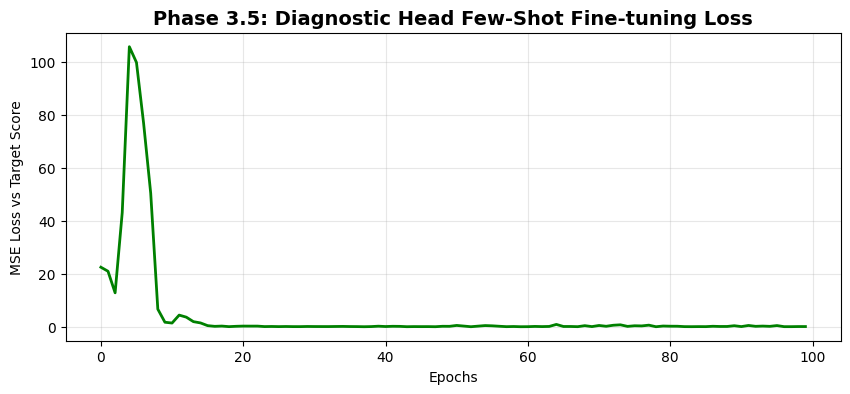


Phase 5: Generating 11 Anomaly Reports...


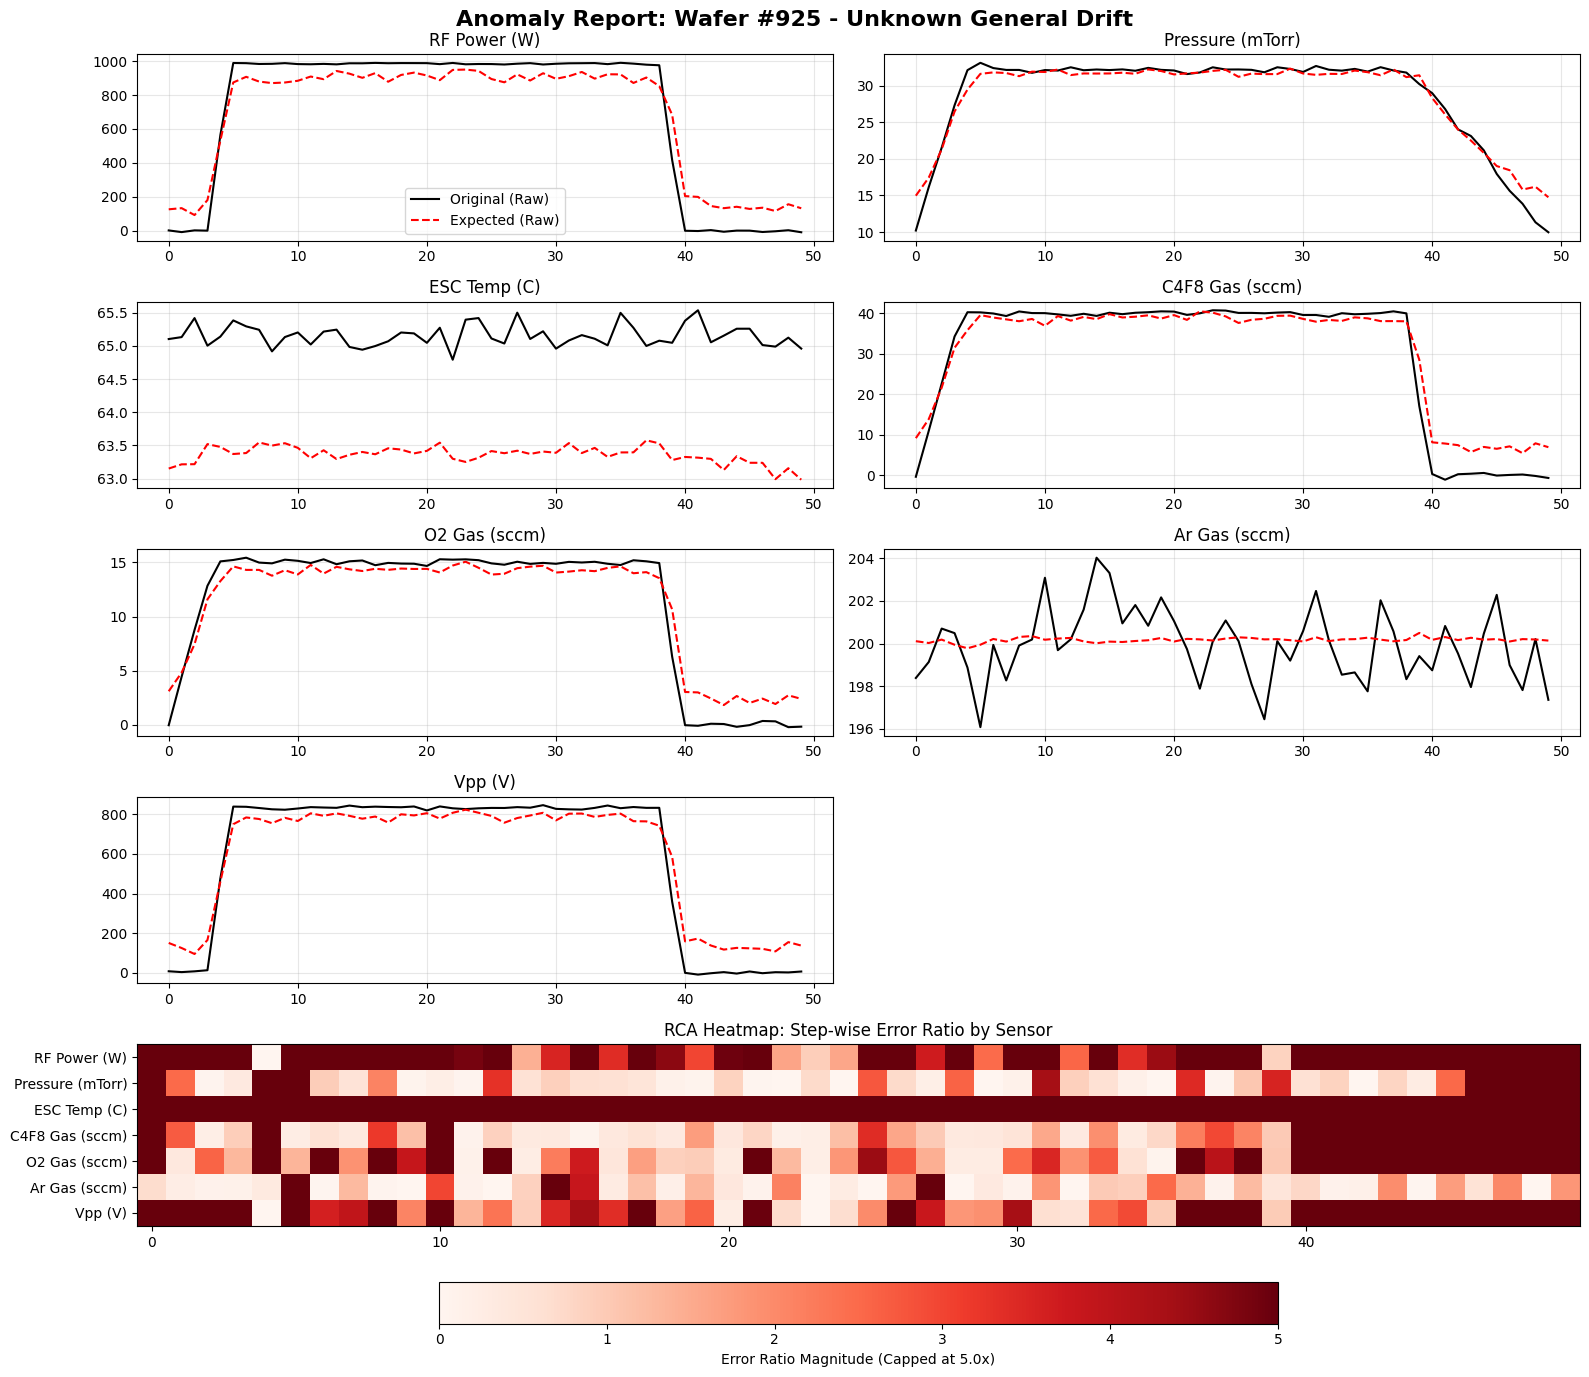


📑 [자동 진단 리포트] Test Wafer #105 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


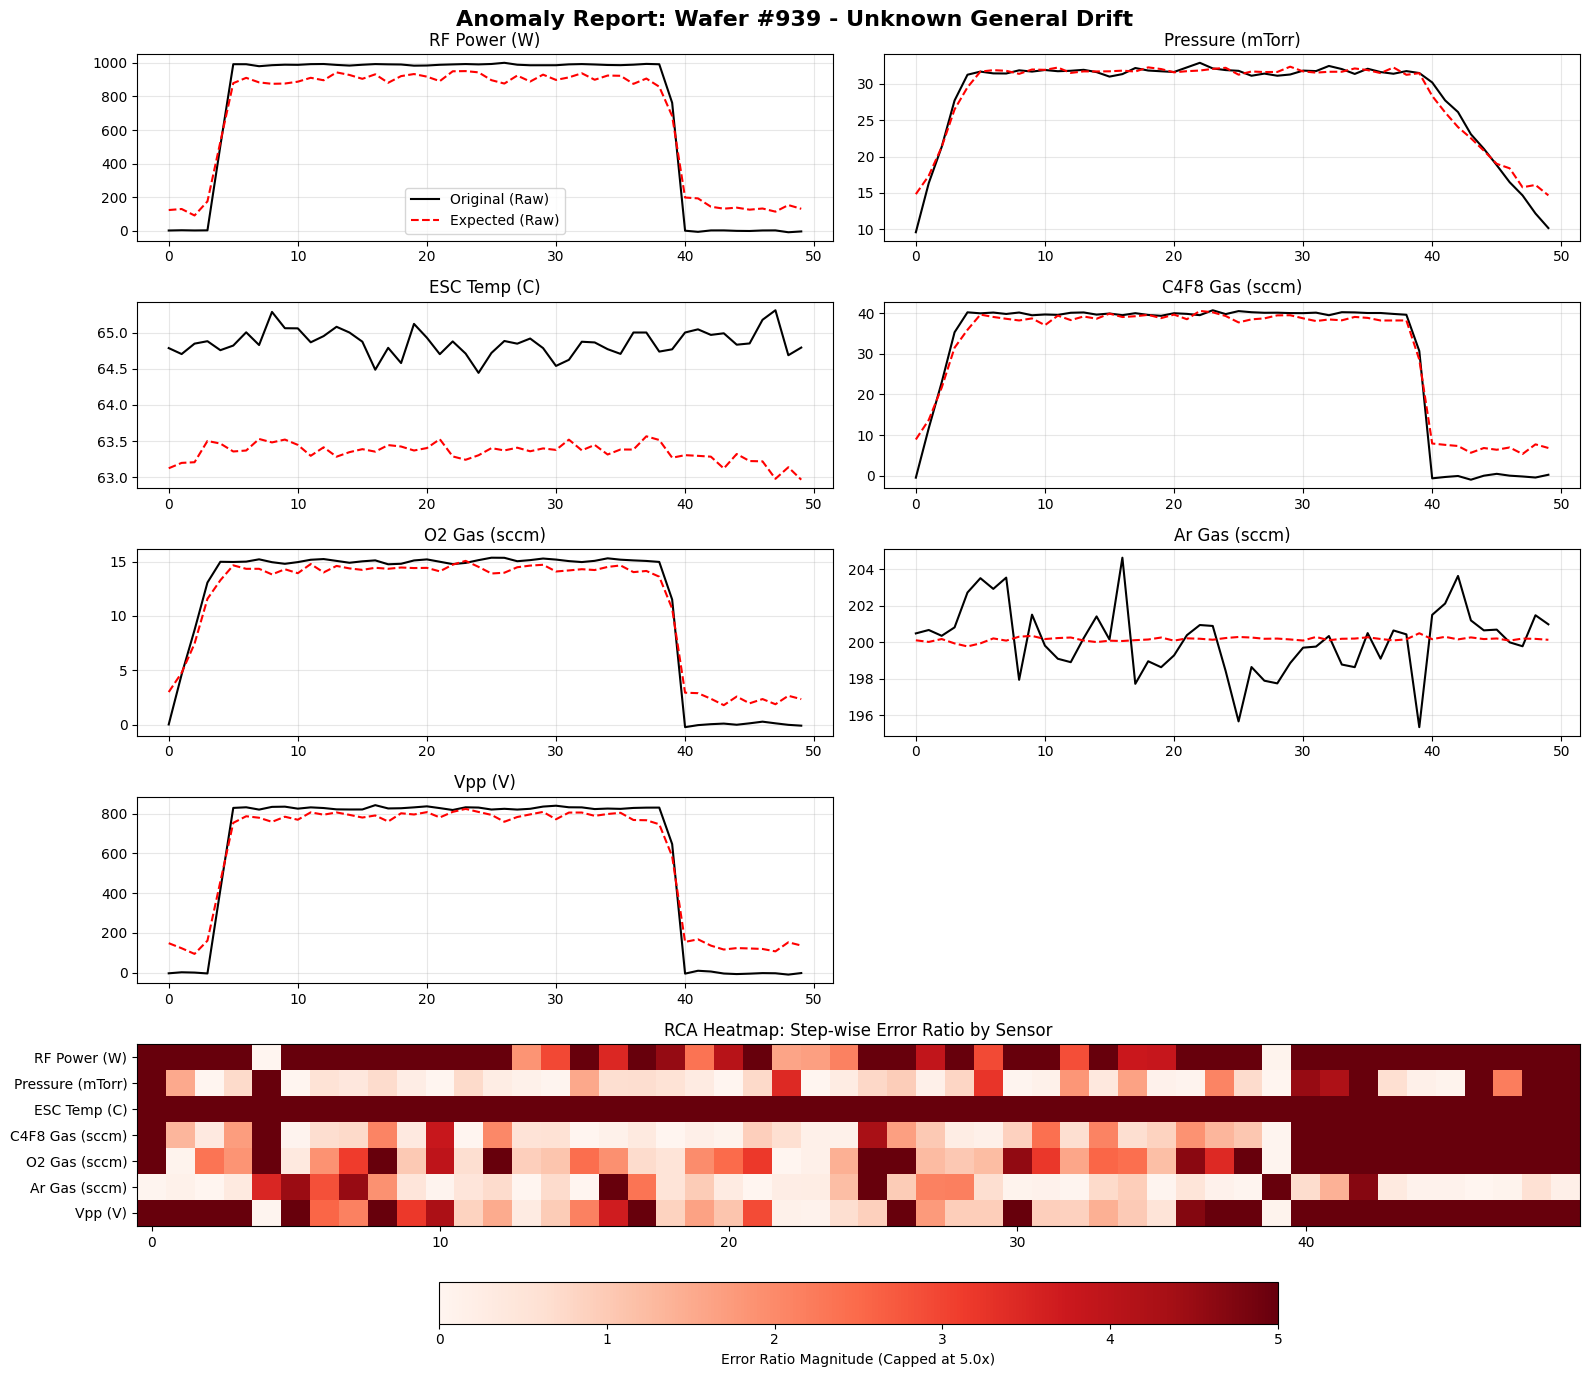


📑 [자동 진단 리포트] Test Wafer #119 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


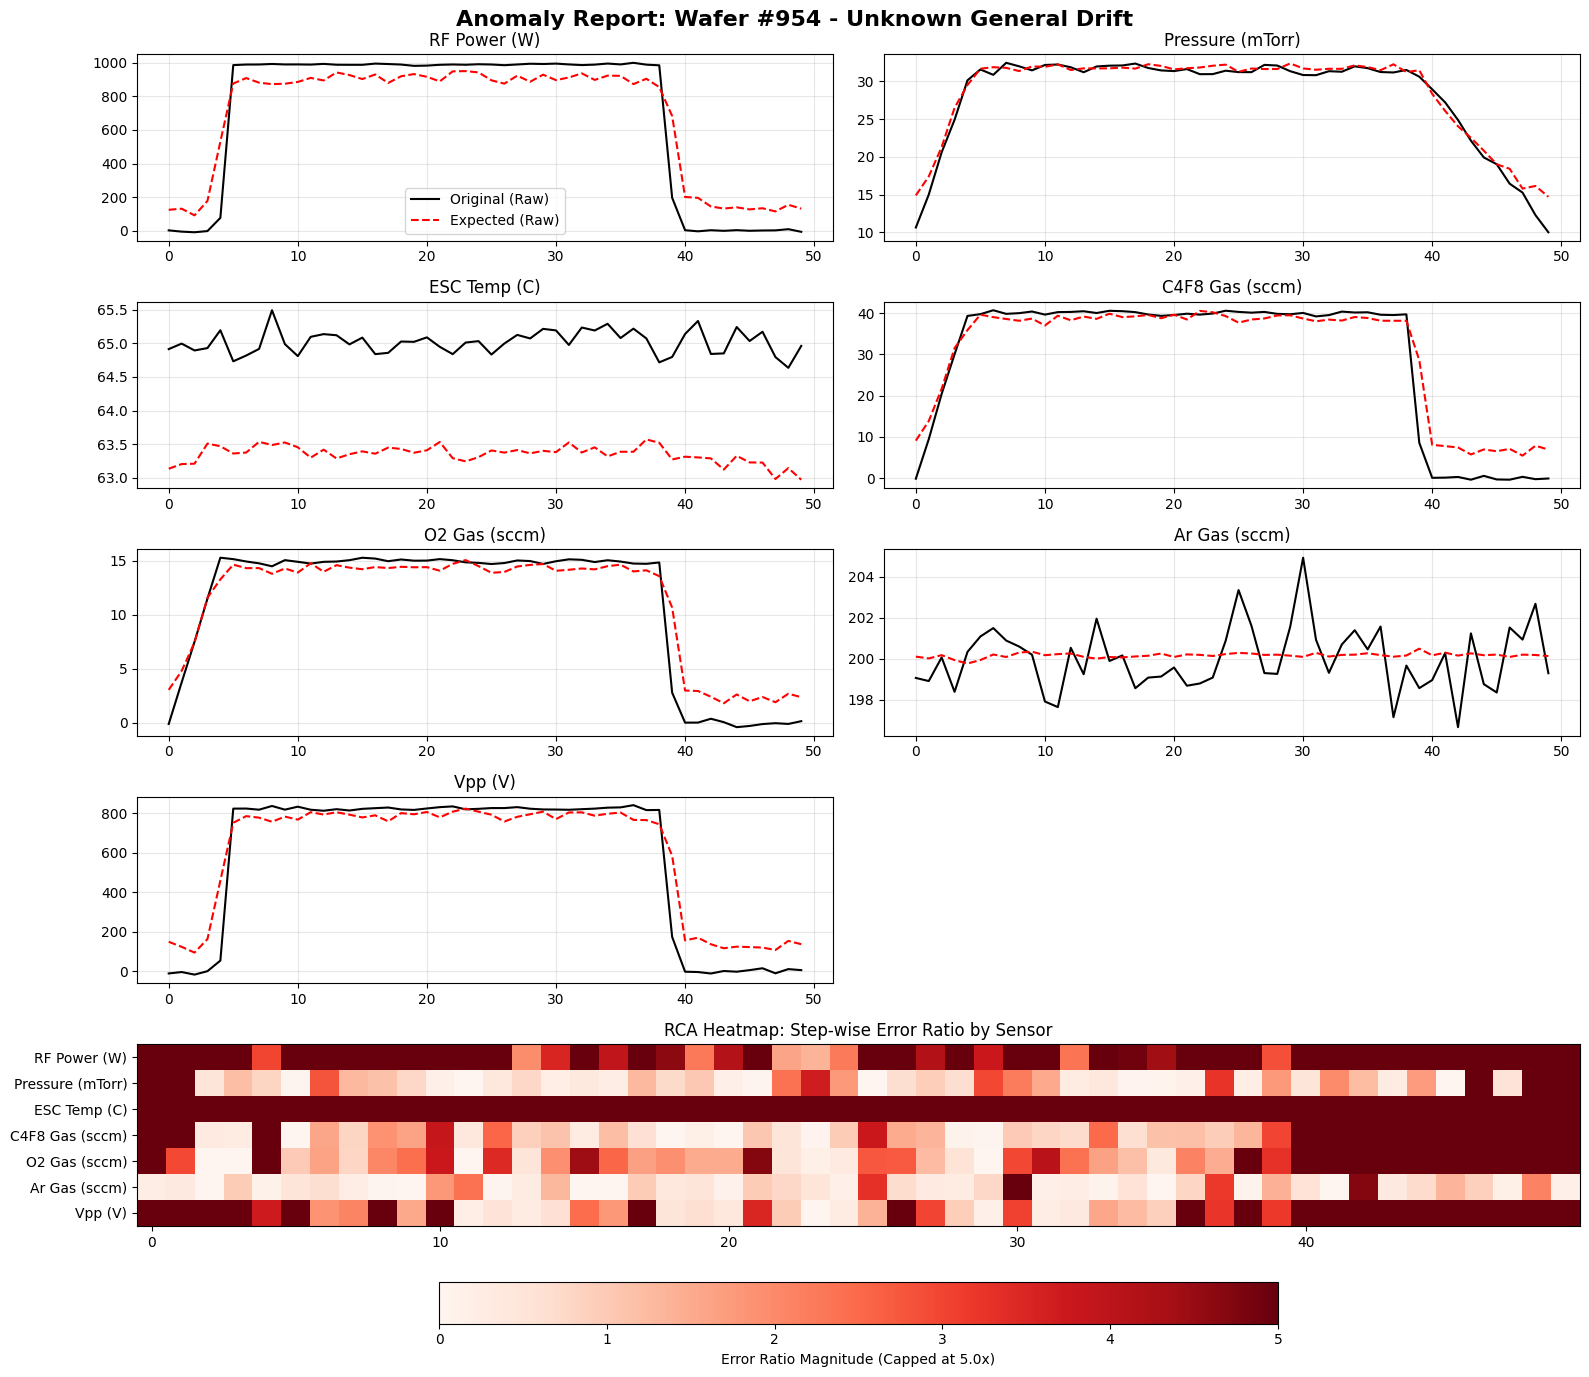


📑 [자동 진단 리포트] Test Wafer #134 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


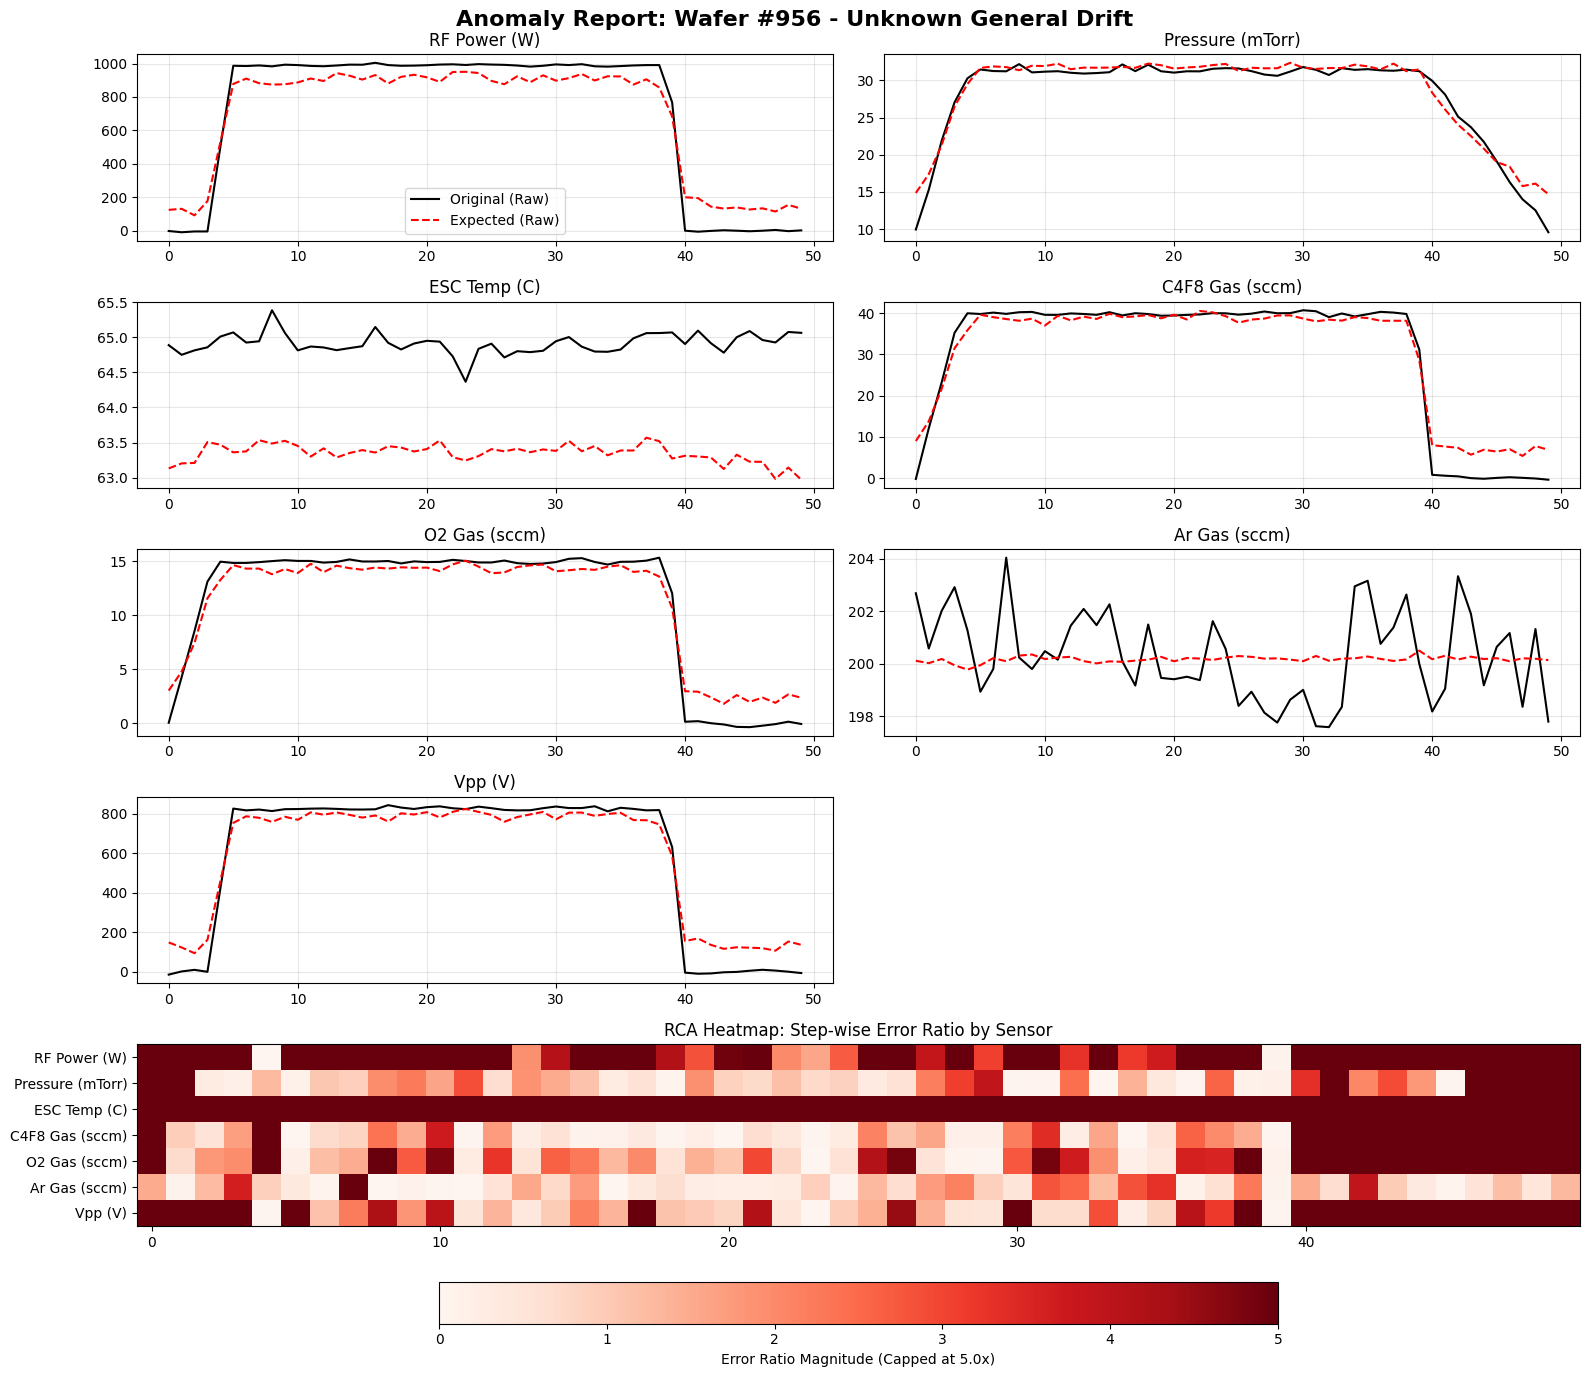


📑 [자동 진단 리포트] Test Wafer #136 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


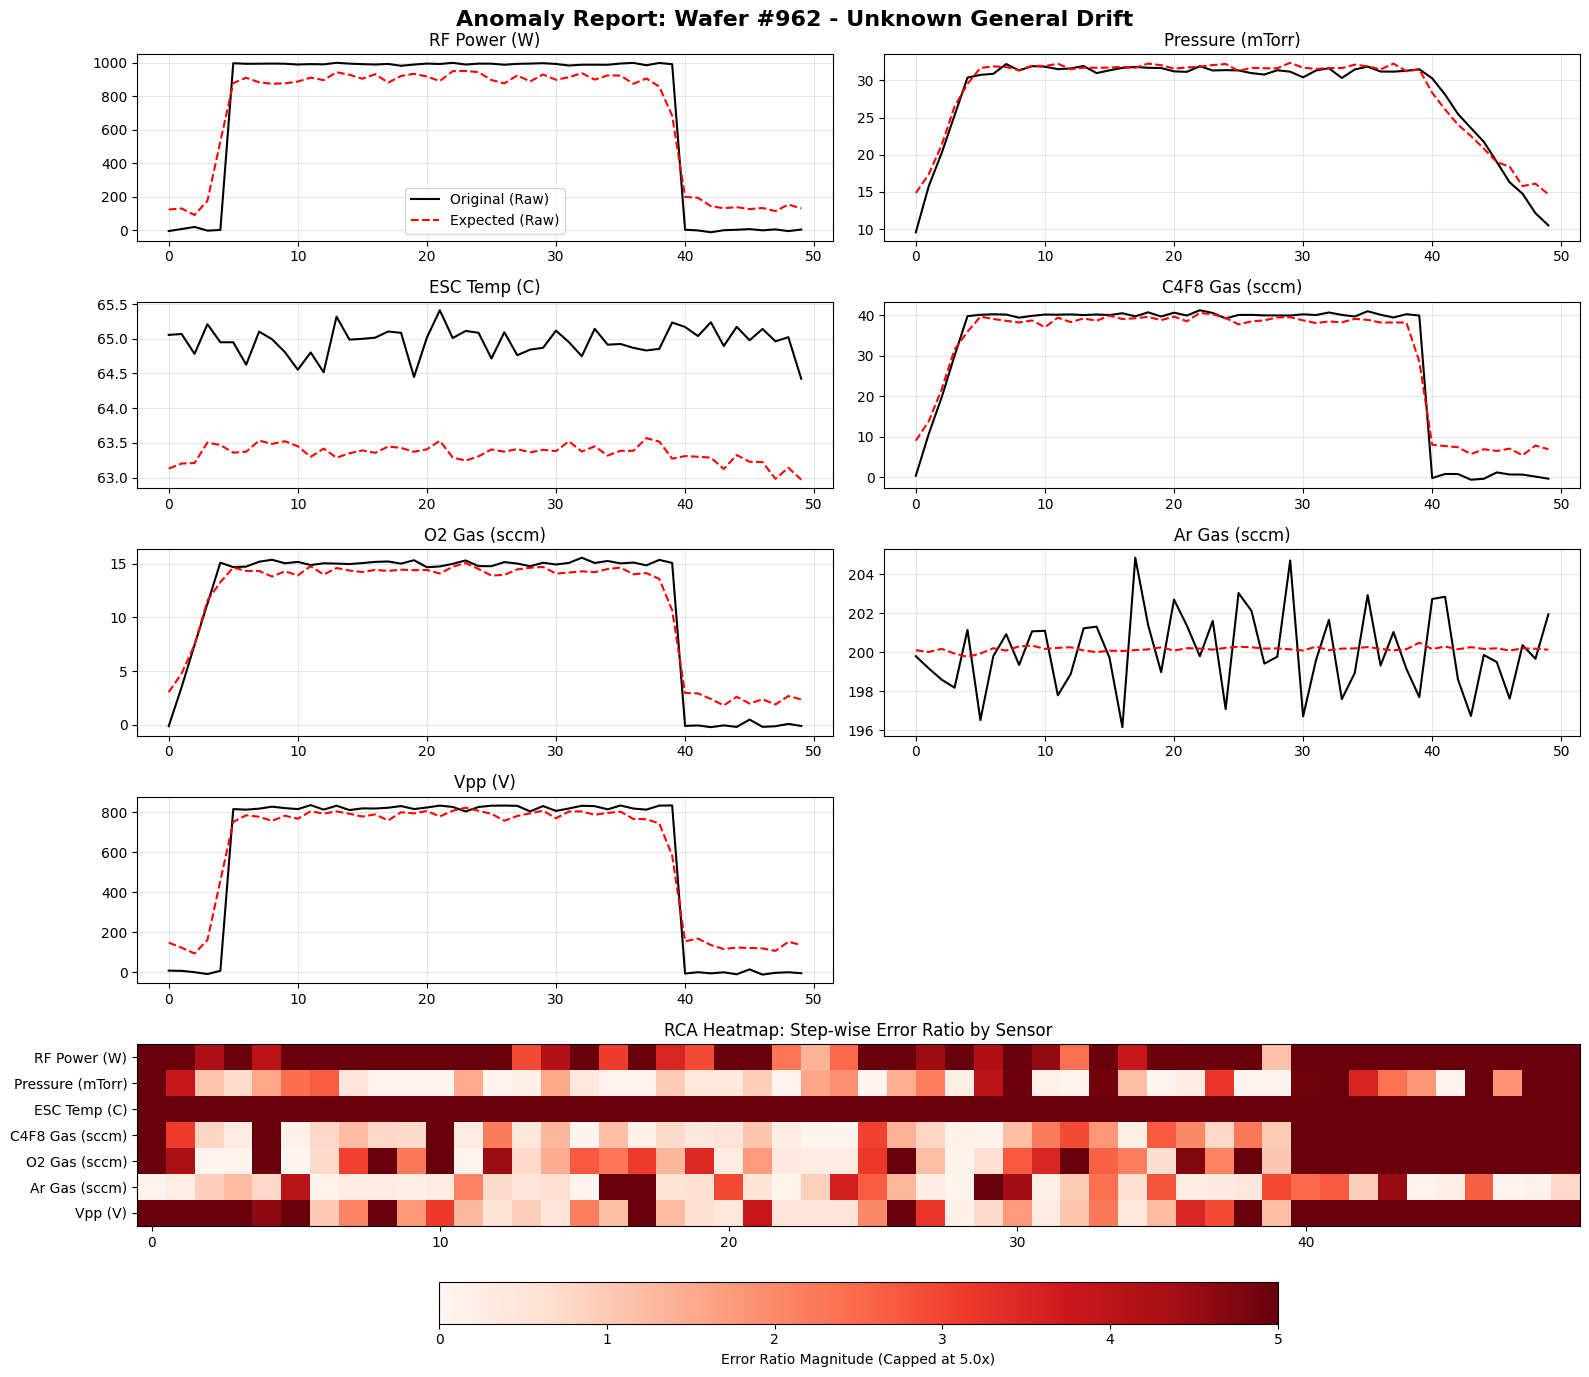


📑 [자동 진단 리포트] Test Wafer #142 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


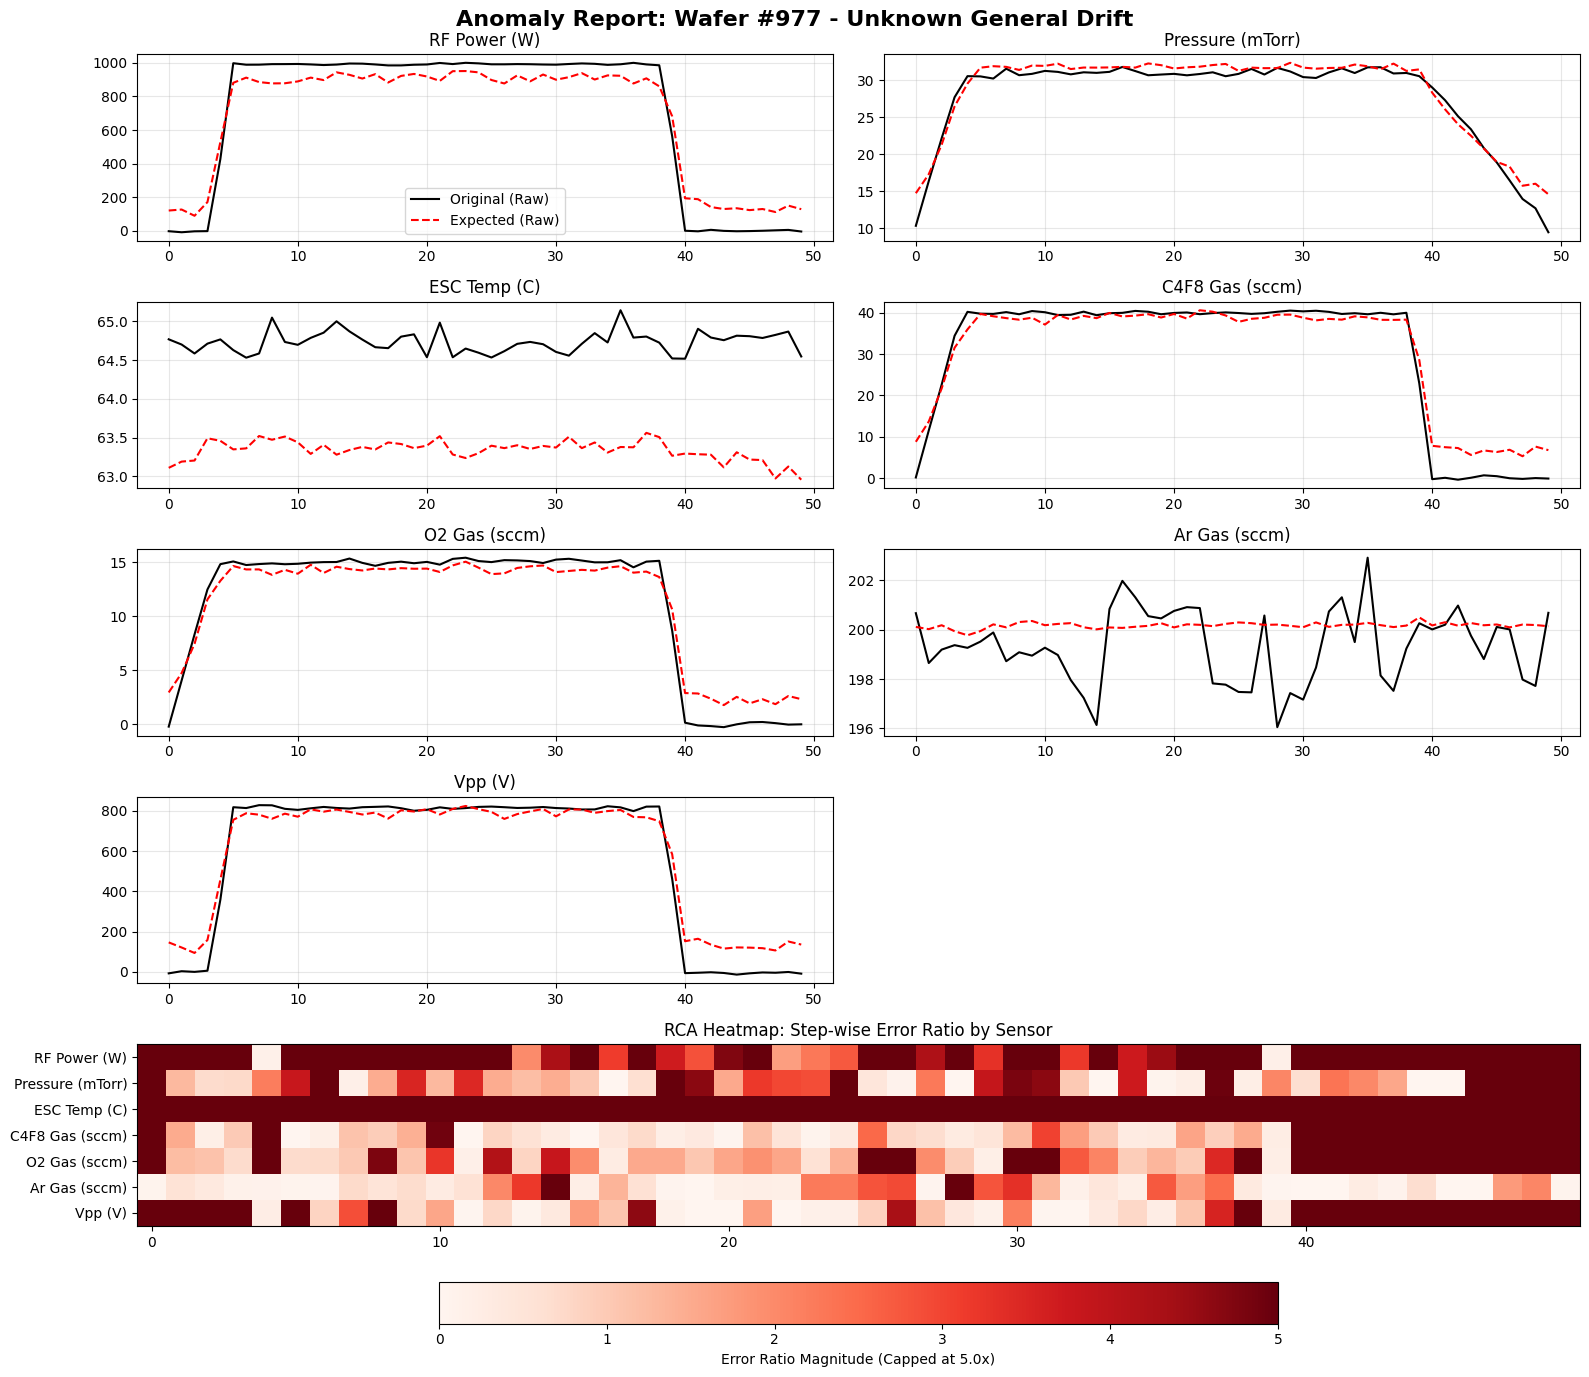


📑 [자동 진단 리포트] Test Wafer #157 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


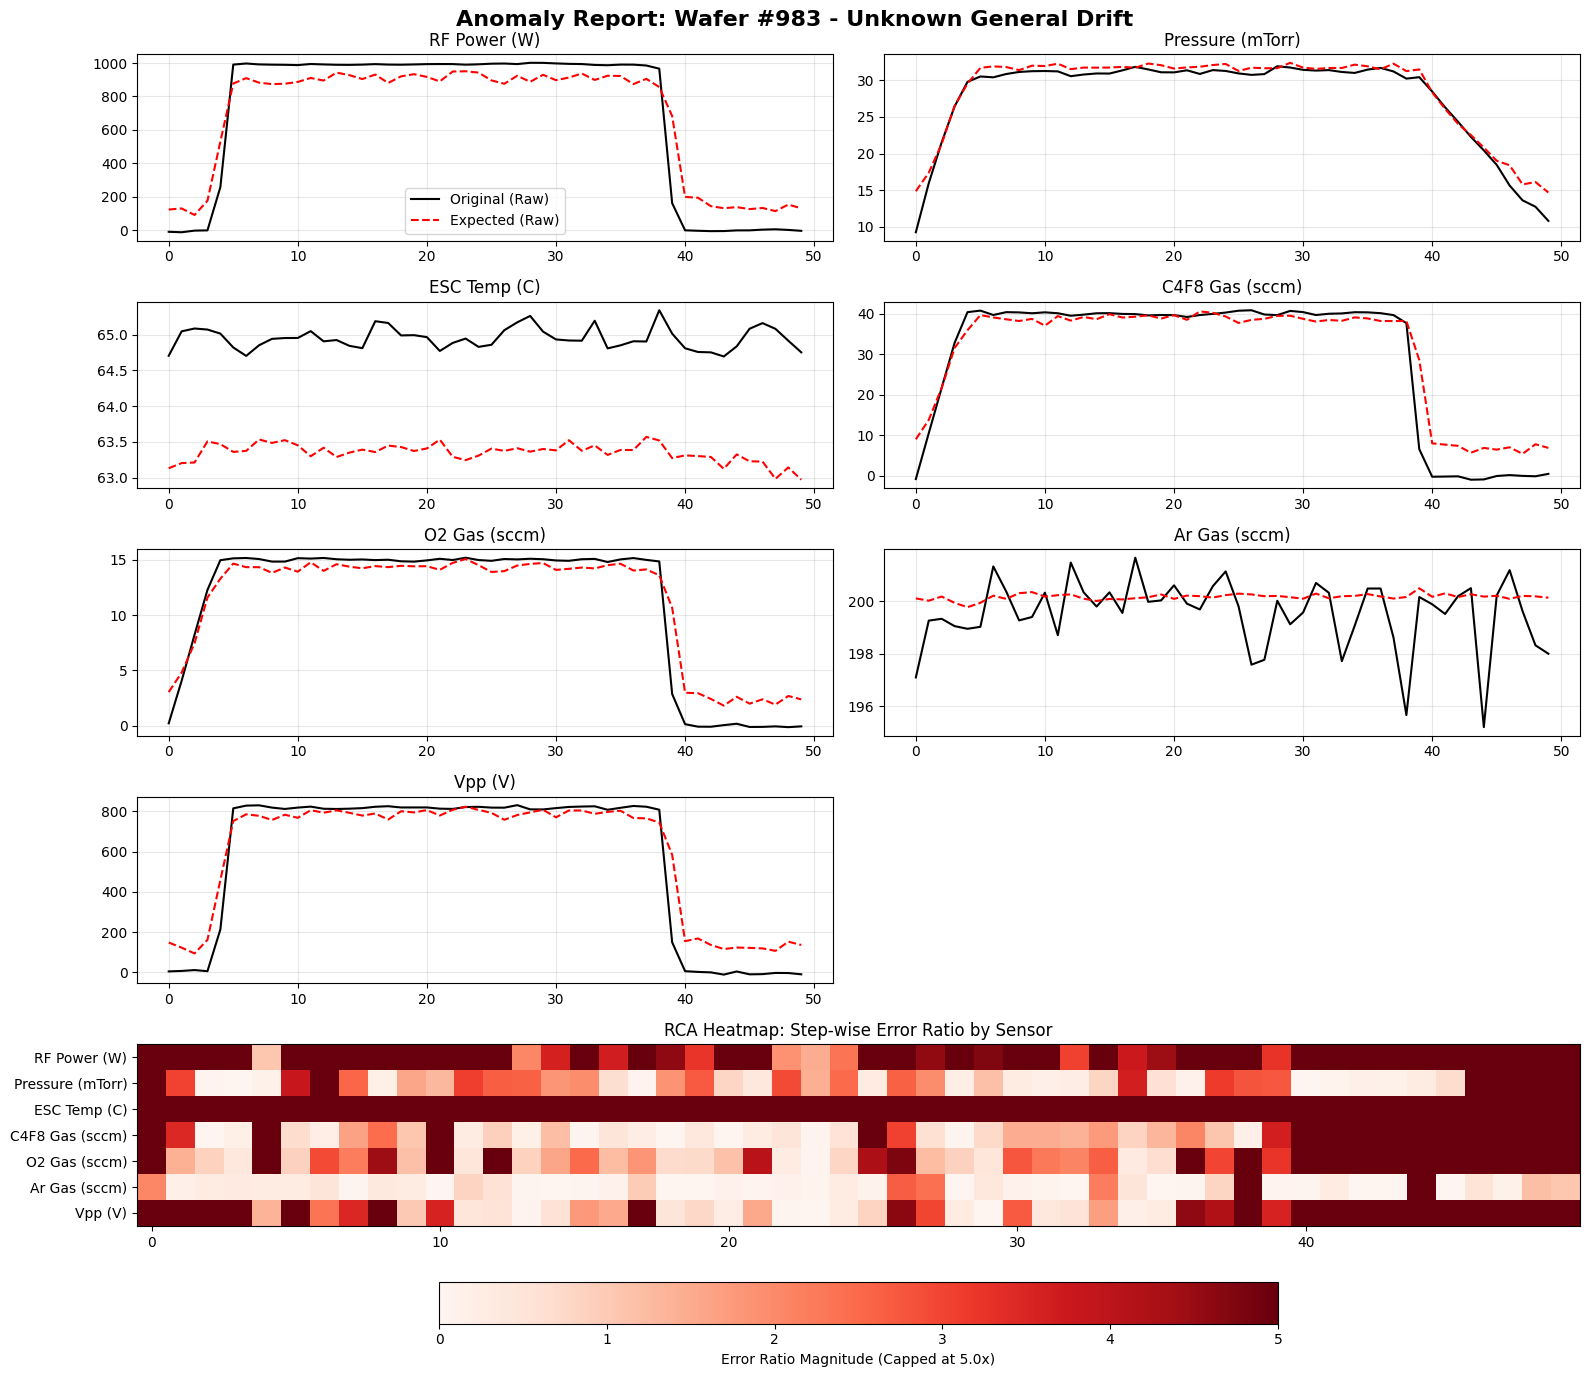


📑 [자동 진단 리포트] Test Wafer #163 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


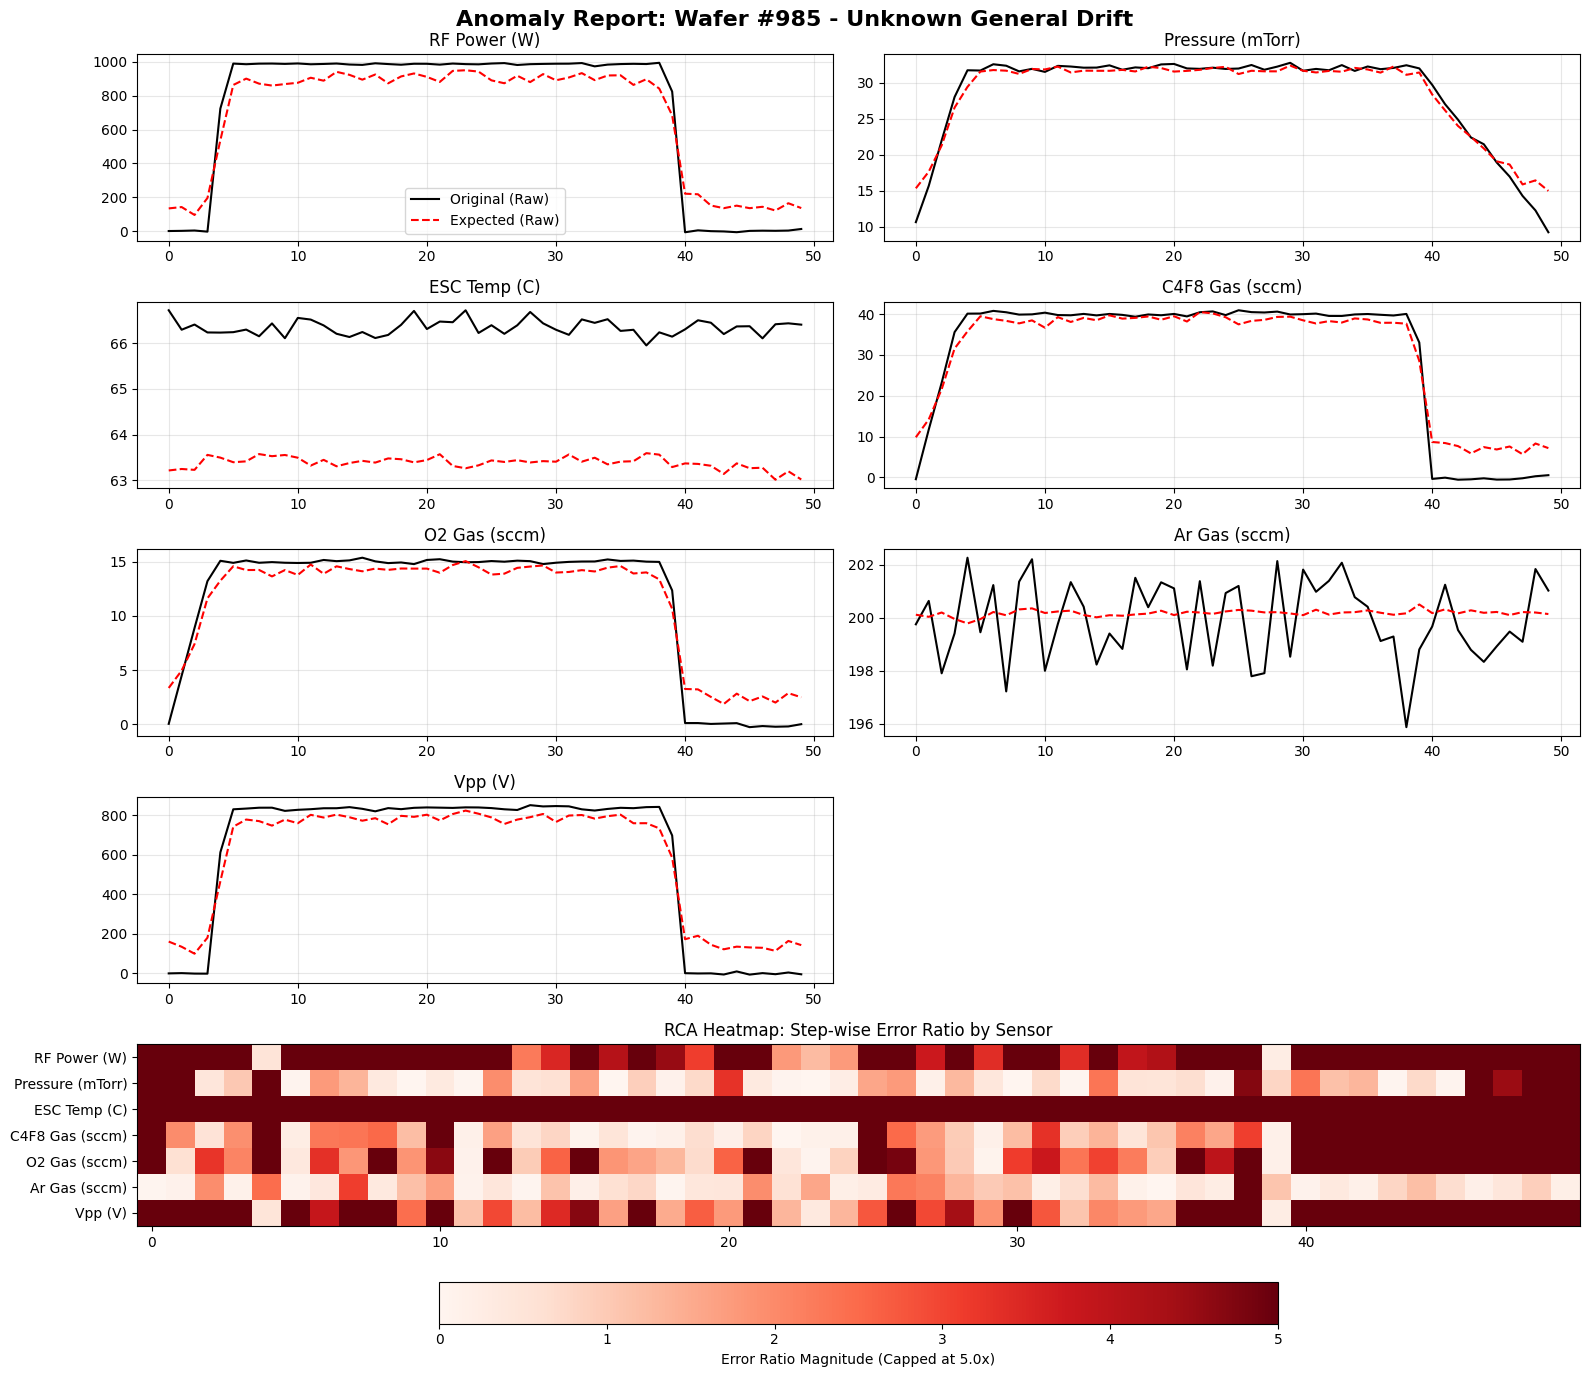


📑 [자동 진단 리포트] Test Wafer #165 불량 분석 요약
   ▶ 인지된 시나리오 타입: 알 수 없는 일반적 이상(General Drift)
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): ESC Temp (C)


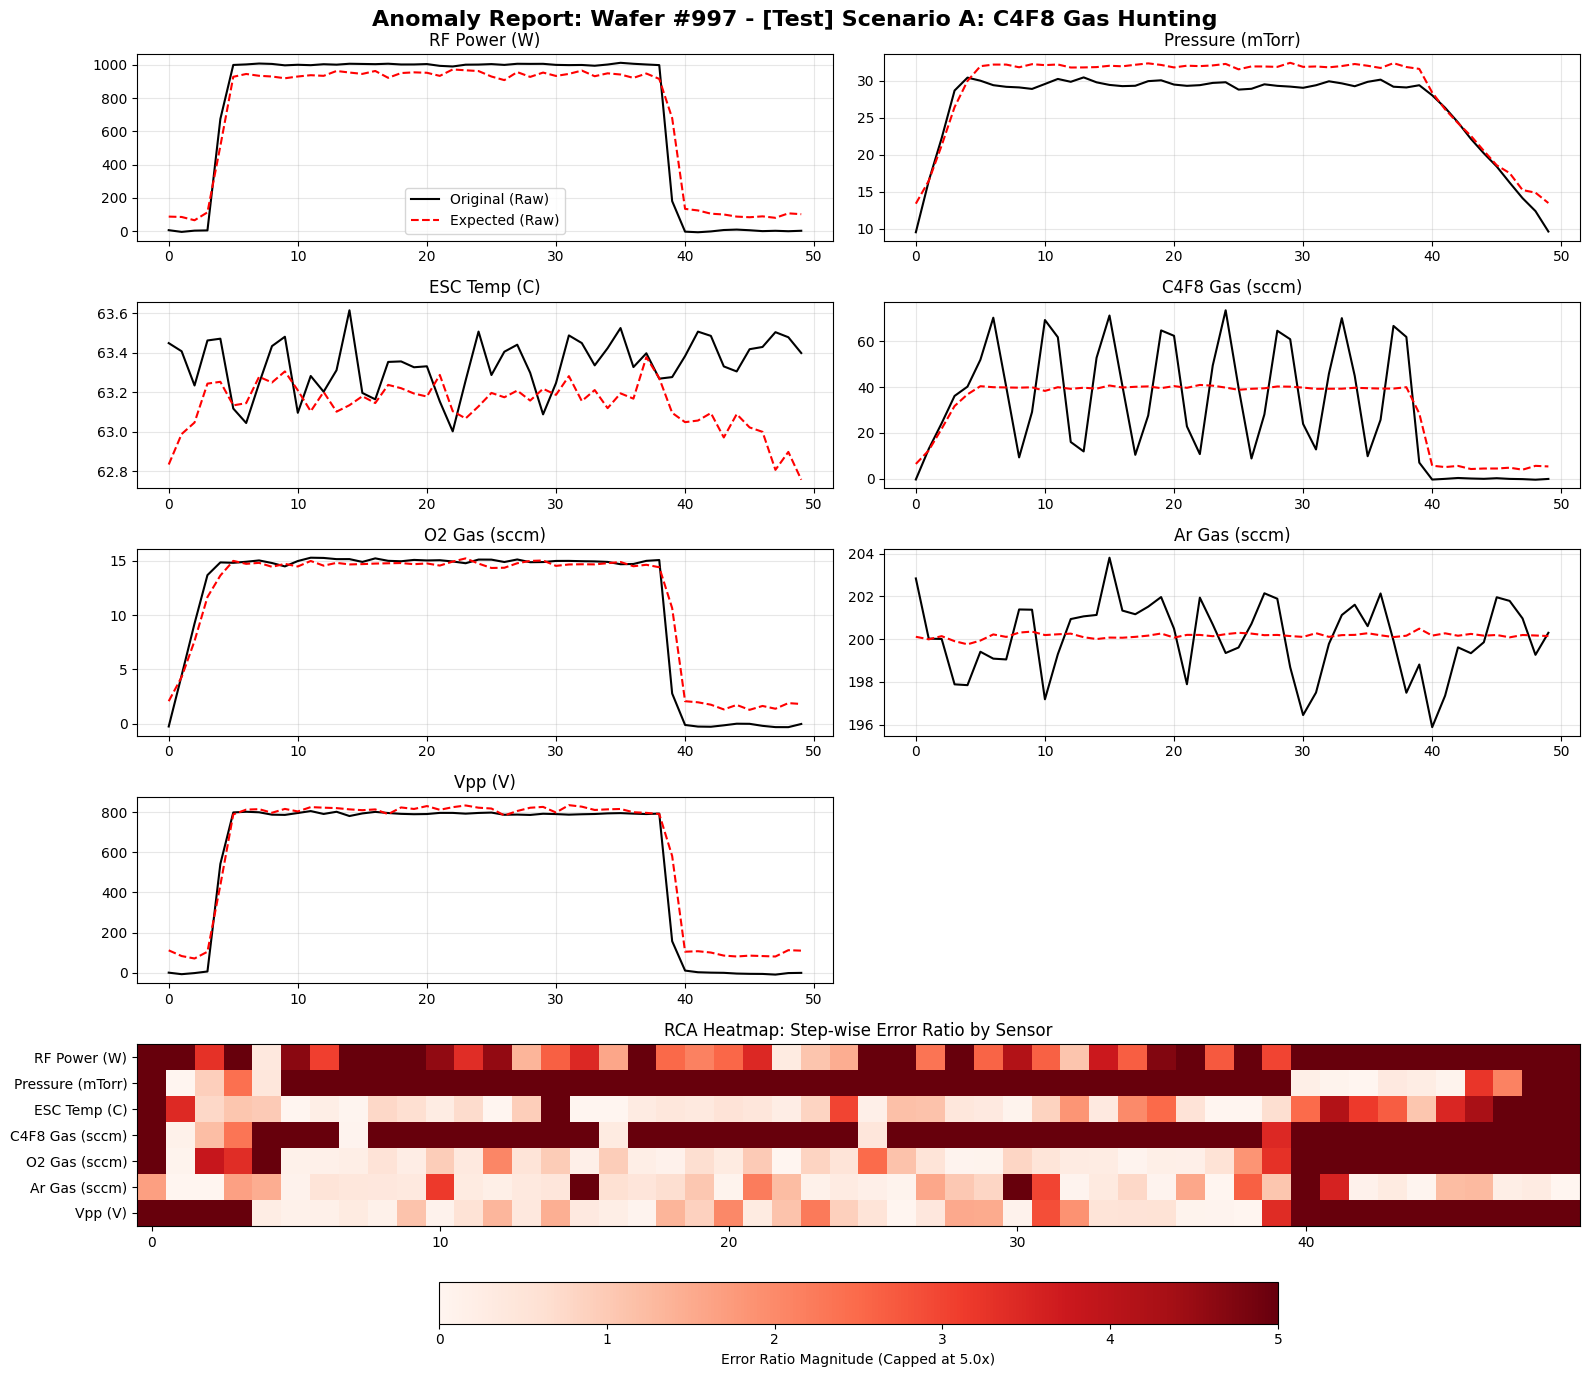


📑 [자동 진단 리포트] Test Wafer #177 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 A: C4F8 Gas 유량 헌팅
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): C4F8 Gas (sccm)


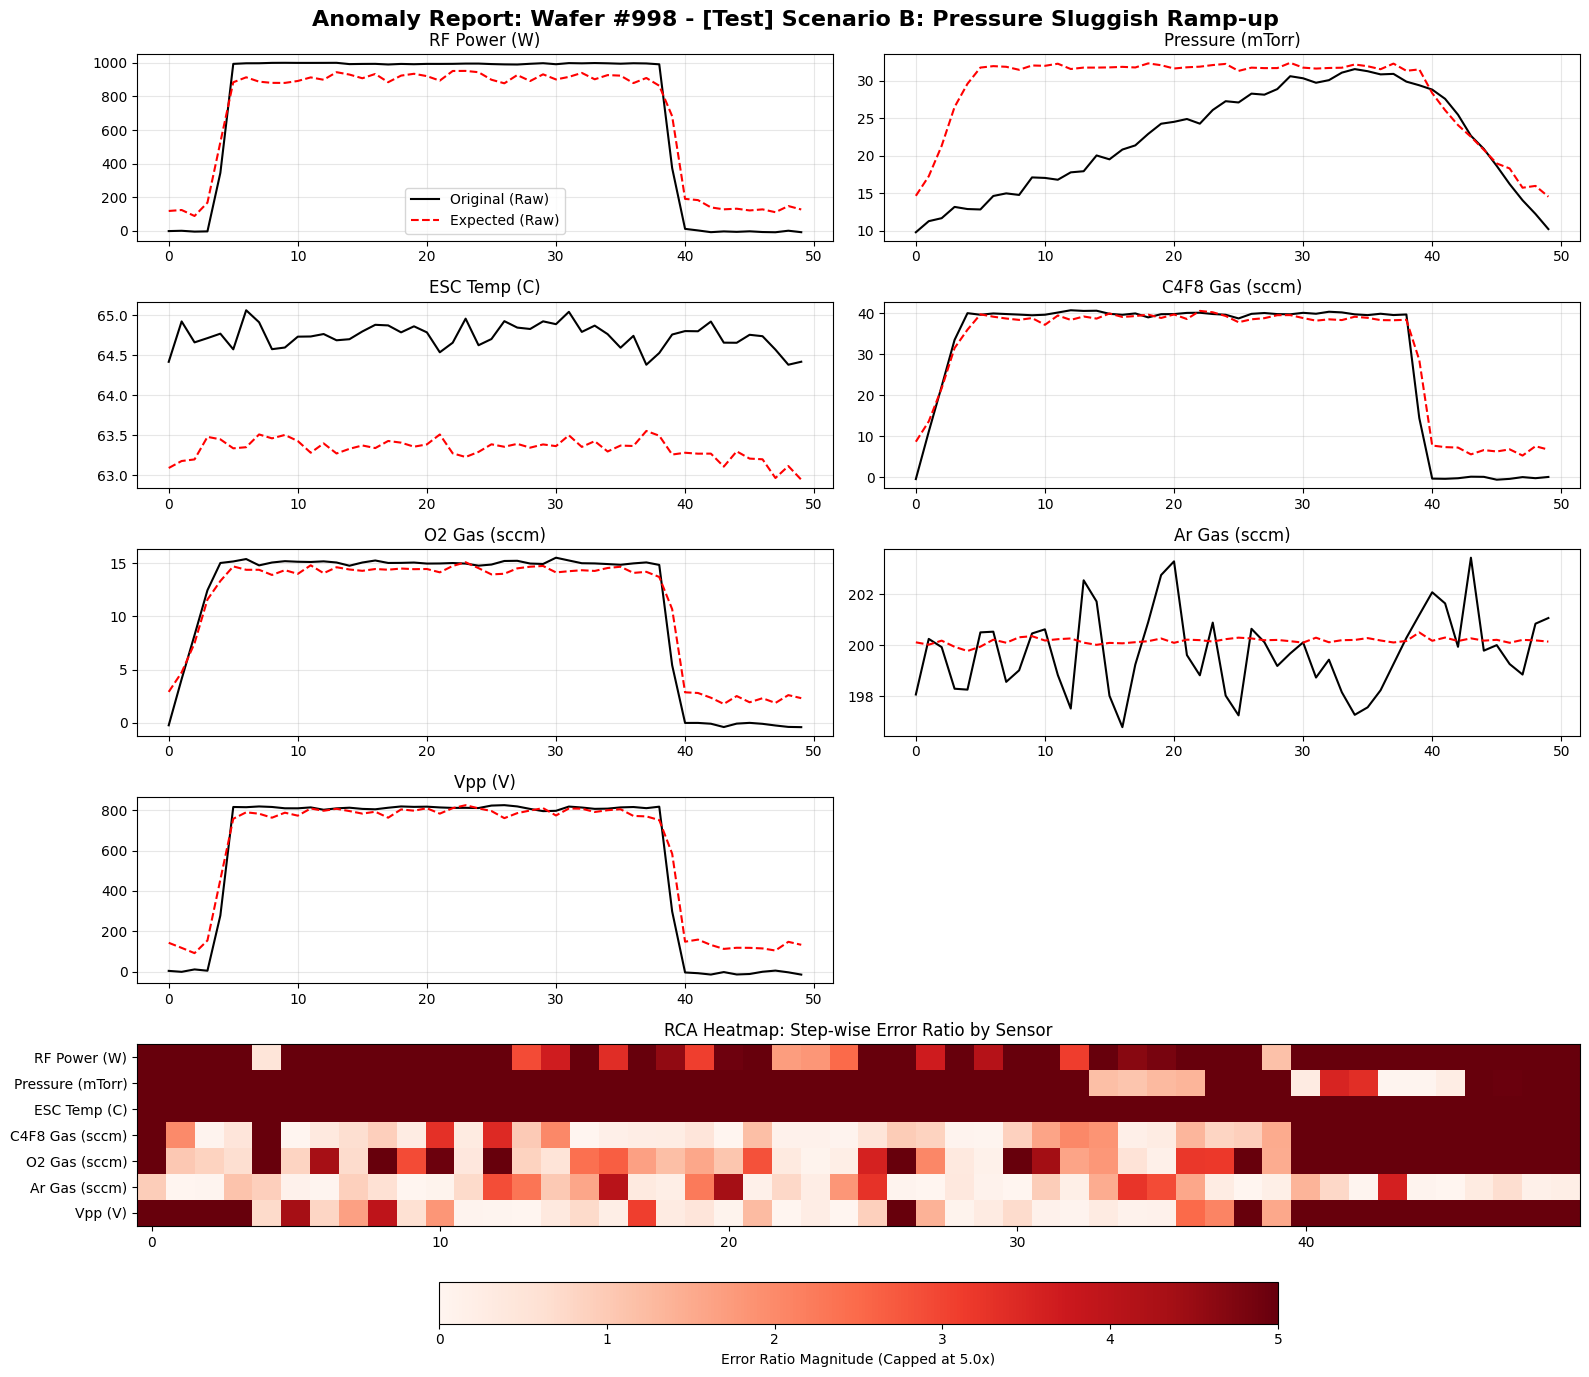


📑 [자동 진단 리포트] Test Wafer #178 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 B: Pressure 초기 도달 지연
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): Pressure (mTorr)


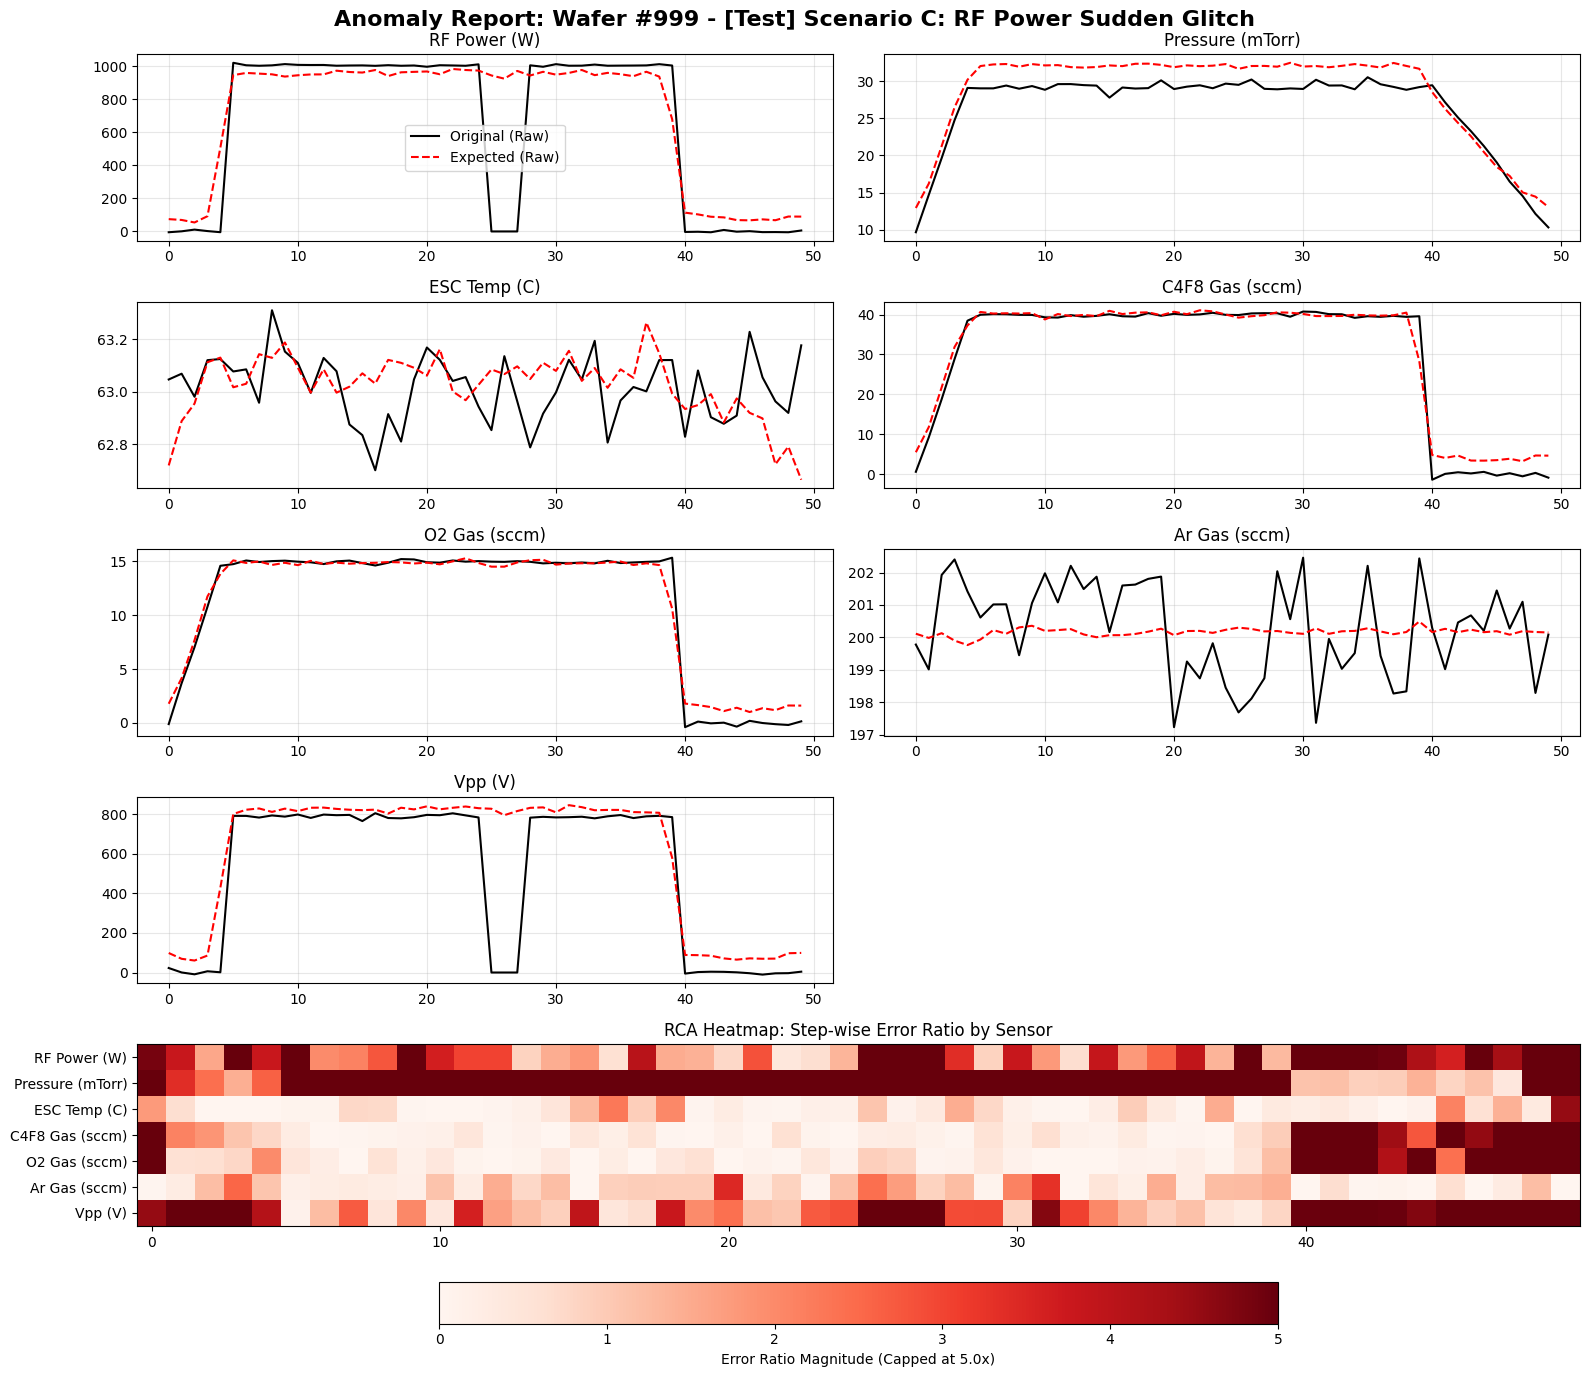


📑 [자동 진단 리포트] Test Wafer #179 불량 분석 요약
   ▶ 인지된 시나리오 타입: [Test] 시나리오 C: RF Power 순간 글리치
🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): RF Power (W), Vpp (V)

Phase 6: Generating PHM Dashboard Plots...


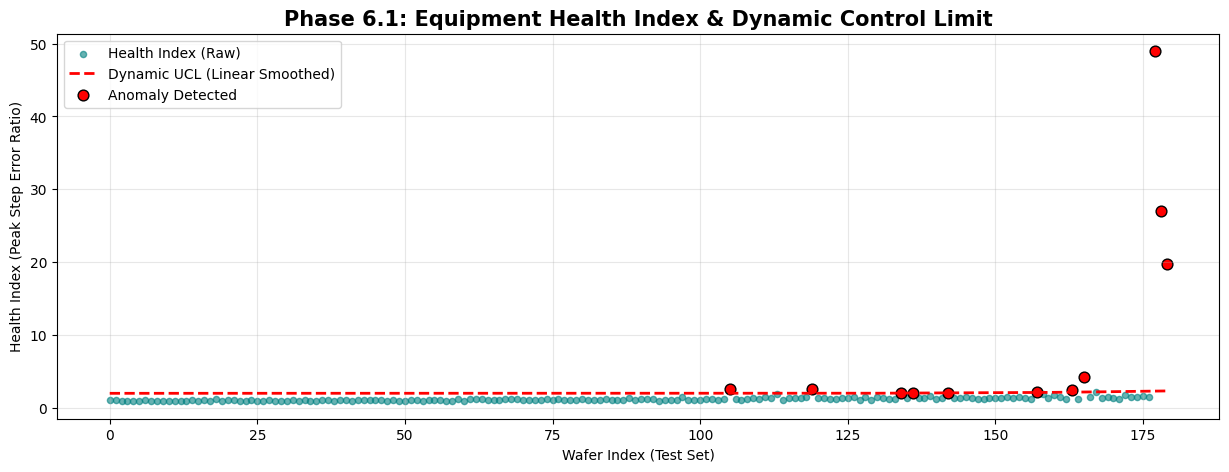

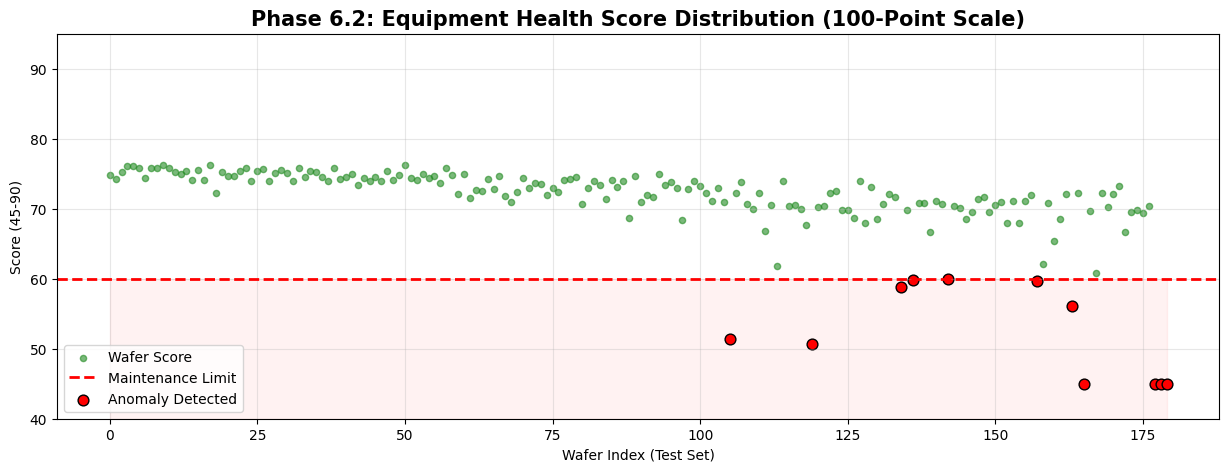

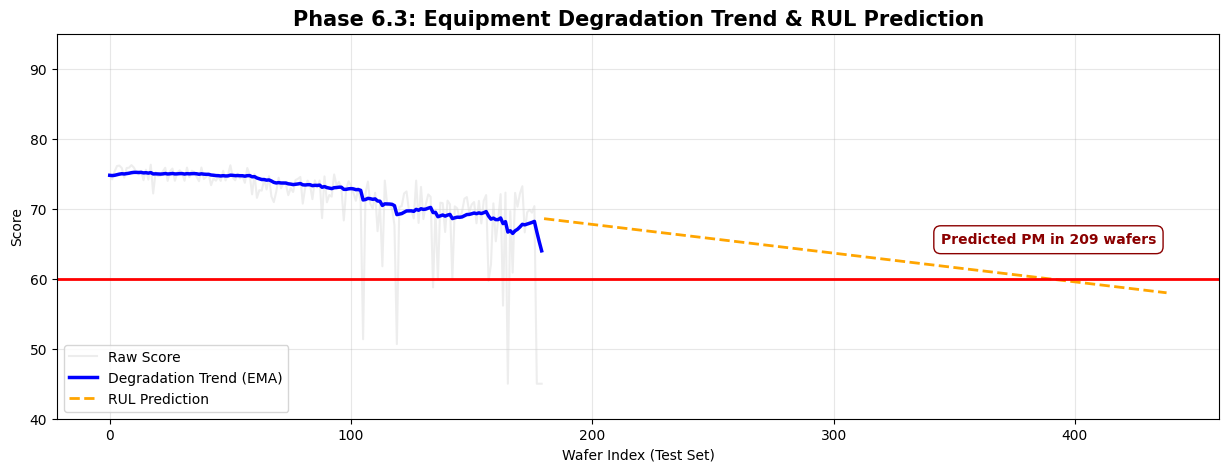


[FDC System Pipeline Summary]
 - Model Architecture: Transformer Encoder-Decoder (Stable Ver.)
 - Normalization: Step-wise Time-aware Error Normalization Applied
 - Few-Shot Setting: apply
 - Detected Anomalies: 11 wafers
 - Avg Health Score: 71.2



In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import math
from scipy.interpolate import interp1d

# 시스템 설정
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[System] Using device: {device}")

# GPU 최적화 (cuDNN Benchmark 활성화)
use_amp = False
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    use_amp = True
    print("-> [Optimize] CUDA AMP (Automatic Mixed Precision) & cuDNN Benchmark Enabled.\n")
else:
    print("\n")

# [옵션] Few-shot learning 적용 여부 선택 ('apply', 'skip', 'both')
# 결과를 바로 확인하시도록 'apply'로 변경했습니다.
FEW_SHOT_OPTION = 'apply'

output_dir = "fdc_outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# ==========================================
# Phase 1: Data Ingestion & Alignment
# ==========================================
print("Phase 1: Loading data, Aligning & Injecting Scenarios...")

data_dir = "factory_data"
trace_csv_path = os.path.join(data_dir, 'raw_fdc_trace.csv')
metro_csv_path = os.path.join(data_dir, 'raw_metrology.csv')

if not os.path.exists(trace_csv_path) or not os.path.exists(metro_csv_path):
    raise FileNotFoundError("Raw data not found. Please run generate_sample_csv.py first.")

df_trace = pd.read_csv(trace_csv_path)
df_metrology = pd.read_csv(metro_csv_path)

sensor_names = ['RF Power (W)', 'Pressure (mTorr)', 'ESC Temp (C)', 'C4F8 Gas (sccm)', 'O2 Gas (sccm)', 'Ar Gas (sccm)', 'Vpp (V)']
NUM_SENSORS = len(sensor_names)
SEQ_LENGTH = 50
FEW_SHOT_SIZE = 20

# 1-1. 웨이퍼 단위 시퀀스 추출
wafer_ids = df_trace['Wafer_ID'].unique()
NUM_WAFERS = len(wafer_ids)
raw_X_list = []
grouped = df_trace.groupby('Wafer_ID')
for w_id in wafer_ids:
    wafer_data = grouped.get_group(w_id)[sensor_names].values
    raw_X_list.append(wafer_data)

y_data = df_metrology['Etch_Depth_nm'].values

scenario_mapping_en = {
    805: "[Few-Shot] Scenario A: C4F8 Gas Hunting",
    810: "[Few-Shot] Scenario B: Pressure Sluggish Ramp-up",
    815: "[Few-Shot] Scenario C: RF Power Sudden Glitch",
    NUM_WAFERS - 3: "[Test] Scenario A: C4F8 Gas Hunting",
    NUM_WAFERS - 2: "[Test] Scenario B: Pressure Sluggish Ramp-up",
    NUM_WAFERS - 1: "[Test] Scenario C: RF Power Sudden Glitch"
}

scenario_mapping_ko = {
    805: "[Few-Shot] 시나리오 A: C4F8 Gas 유량 헌팅",
    810: "[Few-Shot] 시나리오 B: Pressure 초기 도달 지연",
    815: "[Few-Shot] 시나리오 C: RF Power 순간 글리치",
    NUM_WAFERS - 3: "[Test] 시나리오 A: C4F8 Gas 유량 헌팅",
    NUM_WAFERS - 2: "[Test] 시나리오 B: Pressure 초기 도달 지연",
    NUM_WAFERS - 1: "[Test] 시나리오 C: RF Power 순간 글리치"
}

# 1-2. 초고속 시계열 동기화 (1D Interpolation)
X_aligned = []
for w in raw_X_list:
    x_orig = np.linspace(0, 1, len(w))
    x_target = np.linspace(0, 1, SEQ_LENGTH)
    f = interp1d(x_orig, w, axis=0, kind='linear')
    X_aligned.append(f(x_target))
X_data = np.array(X_aligned)

# 1-3. 데이터 저장 (Phase 1 Output)
aligned_records = []
for w_idx in range(NUM_WAFERS):
    for t_idx in range(SEQ_LENGTH):
        aligned_records.append([w_idx, t_idx] + X_data[w_idx, t_idx].tolist())
df_aligned = pd.DataFrame(aligned_records, columns=['Wafer_ID', 'Time_Step'] + sensor_names)
df_aligned.to_csv(os.path.join(output_dir, '01_phase1_aligned_trace.csv'), index=False)

def inject_scenarios(X, y, idx_a, idx_b, idx_c):
    r_step1, r_step2 = int(SEQ_LENGTH * 0.1), int(SEQ_LENGTH * 0.8)
    X[idx_a, r_step1:r_step2, 3] += 20 * np.sin(np.linspace(0, 15 * np.pi, r_step2 - r_step1))
    y[idx_a] -= 25
    X[idx_b, 0:int(SEQ_LENGTH * 0.6), 1] = np.linspace(10, 30, int(SEQ_LENGTH * 0.6)) + np.random.randn(int(SEQ_LENGTH * 0.6)) * 0.5
    y[idx_b] -= 25
    X[idx_c, int(SEQ_LENGTH * 0.5):int(SEQ_LENGTH * 0.5)+3, [0, 6]] = 0
    y[idx_c] -= 25

inject_scenarios(X_data, y_data, 805, 810, 815)
inject_scenarios(X_data, y_data, NUM_WAFERS-3, NUM_WAFERS-2, NUM_WAFERS-1)

# 장비 노후화(Aging Drift) 패턴 주입
idx_test_start = 800 + FEW_SHOT_SIZE
aging_drift = np.linspace(0, 4.0, NUM_WAFERS - idx_test_start)
for i in range(len(aging_drift)):
    X_data[idx_test_start + i, :, 2] += aging_drift[i]

# Phase 1.5: 이상 시나리오 전체 센서 미리보기 시각화
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Phase 1.5: Injected Anomaly Scenarios Preview (All Sensors)', fontsize=16, fontweight='bold')

for i, w_idx in enumerate([NUM_WAFERS - 3, NUM_WAFERS - 2, NUM_WAFERS - 1]):
    scenario_title = scenario_mapping_en[w_idx]
    for s_idx in range(NUM_SENSORS):
        axs[i].plot(X_data[w_idx][:, s_idx], label=sensor_names[s_idx])
    axs[i].set_title(scenario_title, fontweight='bold')
    axs[i].set_ylabel('Raw Value')
    axs[i].grid(True, alpha=0.3)
    if i == 0:
        axs[i].legend(loc='upper right', bbox_to_anchor=(1.15, 1))

axs[-1].set_xlabel('Aligned Time Step')
plt.tight_layout()
plt.show()

# 1-4. 데이터 분할
X_pretrain = X_data[:800]
X_fewshot = X_data[800:idx_test_start]
y_fewshot = y_data[800:idx_test_start]
X_test = X_data[idx_test_start:]
y_test = y_data[idx_test_start:]

is_anomaly_fewshot = (y_fewshot < 140) | (y_fewshot > 160)

scaler = StandardScaler()
X_pretrain_scaled = scaler.fit_transform(X_pretrain.reshape(-1, NUM_SENSORS)).reshape(X_pretrain.shape)
X_fewshot_scaled = scaler.transform(X_fewshot.reshape(-1, NUM_SENSORS)).reshape(X_fewshot.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_SENSORS)).reshape(X_test.shape)

num_workers = min(4, os.cpu_count() or 1)
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pretrain_scaled)), batch_size=128, shuffle=True, num_workers=num_workers, pin_memory=True)
fewshot_loader = DataLoader(TensorDataset(torch.FloatTensor(X_fewshot_scaled), torch.BoolTensor(is_anomaly_fewshot)), batch_size=4, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_scaled)), batch_size=64, shuffle=False, num_workers=num_workers, pin_memory=True)

# ==========================================
# Phase 2: Transformer Foundation Model
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :].unsqueeze(0)
        return x

class FDCEncoder(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=16):
        super(FDCEncoder, self).__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=2048, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc_latent = nn.Linear(d_model, latent_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.fc_latent(x.mean(dim=1))

class FDCDecoder(nn.Module):
    def __init__(self, latent_dim, d_model=64, nhead=4, num_layers=2, output_dim=7, seq_len=50):
        super(FDCDecoder, self).__init__()
        self.seq_len = seq_len
        self.latent_proj = nn.Linear(latent_dim, d_model * seq_len)
        self.pos_encoder = PositionalEncoding(d_model)
        dec_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=2048, batch_first=True)
        self.transformer = nn.TransformerEncoder(dec_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, latent):
        batch_size = latent.size(0)
        x = self.latent_proj(latent).view(batch_size, self.seq_len, -1)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.fc_out(x)

class FDCFoundationModel(nn.Module):
    def __init__(self, input_dim=NUM_SENSORS, d_model=64, latent_dim=16, seq_len=50):
        super(FDCFoundationModel, self).__init__()
        self.encoder = FDCEncoder(input_dim, d_model, nhead=4, num_layers=2, latent_dim=latent_dim)
        self.decoder = FDCDecoder(latent_dim, d_model, nhead=4, num_layers=2, output_dim=input_dim, seq_len=seq_len)
    def forward(self, x):
        return self.decoder(self.encoder(x))

foundation_model = FDCFoundationModel(input_dim=NUM_SENSORS, seq_len=SEQ_LENGTH).to(device)

MODEL_SAVE_PATH = os.path.join(data_dir, 'foundation_model_v4_reverted.pth')
TRAIN_LOSS_CSV = os.path.join(output_dir, '02_phase2_train_loss.csv')

def train_foundation_model():
    print("Phase 2: Training Transformer Foundation Model (Architecture Reverted)...")
    optimizer = optim.Adam(foundation_model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    scaler_amp = torch.amp.GradScaler('cuda') if use_amp else None

    pretrain_losses = []
    for epoch in range(30):
        foundation_model.train()
        epoch_loss = 0
        for (bx,) in train_loader:
            bx = bx.to(device, non_blocking=True)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=use_amp):
                recon = foundation_model(bx)
                loss = criterion(recon, bx)

            if use_amp:
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
            else:
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            print(f"   Epoch [{epoch+1}/30], Loss: {epoch_loss/len(train_loader):.4f}")
        pretrain_losses.append(epoch_loss / len(train_loader))

    torch.save(foundation_model.state_dict(), MODEL_SAVE_PATH)
    pd.DataFrame({'epoch': range(len(pretrain_losses)), 'loss': pretrain_losses}).to_csv(TRAIN_LOSS_CSV, index=False)
    print("-> Phase 2 training completed.")

if os.path.exists(MODEL_SAVE_PATH):
    try:
        print("Phase 2: Loading pre-trained model...")
        foundation_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    except RuntimeError:
        print("-> [Warning] Model architecture mismatch. Restarting training...")
        train_foundation_model()
else:
    train_foundation_model()

if os.path.exists(TRAIN_LOSS_CSV):
    df_loss = pd.read_csv(TRAIN_LOSS_CSV)
    plt.figure(figsize=(10, 4))
    plt.plot(df_loss['epoch'], df_loss['loss'], color='purple', marker='o', linewidth=2)
    plt.title('Phase 2.5: Foundation Model Pre-training Loss Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# Phase 3 & UCL 로직 (현업 친화적 선형 스무딩 적용)
# ==========================================
class FDCDiagnosticHead(nn.Module):
    def __init__(self, num_sensors):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(num_sensors, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1), nn.Softplus())
    def forward(self, x): return self.net(x).squeeze(-1)

diagnostic_head = FDCDiagnosticHead(NUM_SENSORS).to(device)

def get_stable_metrics(model, diag_head=None):
    model.eval()
    if diag_head: diag_head.eval()
    with torch.no_grad():
        train_errs = []
        for (bx,) in train_loader:
            bx = bx.to(device, non_blocking=True)
            r = model(bx).cpu()
            train_errs.append(((r - bx.cpu())**2).numpy())

        train_errs = np.concatenate(train_errs, axis=0) # shape: (800, 50, 7)
        norm_mse_step = np.mean(train_errs, axis=0) + 0.005 # shape: (50, 7)

        train_ratios = train_errs / norm_mse_step

        # [Fix] Few-shot 모델의 초기 히스토리가 파운데이션 모델 기준값과 틀어지지 않도록,
        # 훈련 데이터에 대한 초기 100장의 히스토리도 Diagnostic Head를 태워 기준을 맞춰줍니다.
        if diag_head:
            train_h_vals = []
            for i in range(train_ratios.shape[0]):
                max_ratio_per_sensor = np.max(train_ratios[i], axis=0)
                h_val = diag_head((torch.FloatTensor(max_ratio_per_sensor).to(device)).unsqueeze(0)).item()
                train_h_vals.append(h_val)
            train_h_vals = np.array(train_h_vals)
        else:
            train_h_vals = np.max(train_ratios, axis=(1, 2))

        test_h, test_ucl, outliers = [], [], []
        ucl_history = list(train_h_vals[-100:])

        # [신규] UCL 선형 변동(Linear Smoothing)을 위한 초기값 설정
        smoothed_ucl = max(np.mean(ucl_history) + 6 * np.std(ucl_history), 2.0)

        for (bx,) in test_loader:
            bx = bx.to(device, non_blocking=True)
            r = model(bx).cpu()

            batch_errs = ((r - bx.cpu())**2).numpy() # shape: (batch, 50, 7)
            batch_ratios = batch_errs / norm_mse_step

            for i in range(batch_errs.shape[0]):
                ratio_matrix = batch_ratios[i] # shape: (50, 7)

                if diag_head:
                    max_ratio_per_sensor = np.max(ratio_matrix, axis=0)
                    h_val = diag_head((torch.FloatTensor(max_ratio_per_sensor).to(device)).unsqueeze(0)).item()
                else:
                    h_val = np.max(ratio_matrix)

                raw_ucl = max(np.mean(ucl_history) + 6 * np.std(ucl_history), 2.0)

                # [핵심 로직] 지수 이동 평균(EMA)을 통한 현업 친화형 선형 UCL 업데이트
                # 이전 UCL 관성을 95% 유지하고, 새로운 데이터의 영향을 5%만 반영하여
                # Few-shot 적용 시 요동치는 노이즈를 완벽하게 제거하고 부드러운 선형 추세를 만듭니다.
                smoothed_ucl = 0.95 * smoothed_ucl + 0.05 * raw_ucl

                test_h.append(h_val)
                test_ucl.append(smoothed_ucl)

                if h_val > smoothed_ucl:
                    outliers.append(len(test_h)-1)
                else:
                    ucl_history.append(h_val)
                    ucl_history.pop(0)

    return test_h, test_ucl, outliers, norm_mse_step

if FEW_SHOT_OPTION in ['skip', 'both']:
    h_before, ucl_before, out_before, nmse_before = get_stable_metrics(foundation_model)

FEWSHOT_LOSS_CSV = os.path.join(output_dir, '03_phase3_fewshot_loss.csv')
if FEW_SHOT_OPTION in ['apply', 'both']:
    print("Phase 3: Fine-tuning Diagnostic Head...")
    for p in foundation_model.parameters(): p.requires_grad = False
    opt_h = optim.Adam(diagnostic_head.parameters(), lr=0.005)
    crit_h = nn.MSELoss()
    scaler_amp = torch.amp.GradScaler('cuda') if use_amp else None

    temp_errs = []
    with torch.no_grad():
        for (bx,) in train_loader:
            bx = bx.to(device, non_blocking=True)
            temp_errs.append(((foundation_model(bx).cpu() - bx.cpu())**2).numpy())
    temp_errs = np.concatenate(temp_errs, axis=0)
    nmse_step = np.mean(temp_errs, axis=0) + 0.005
    nmse_tensor = torch.FloatTensor(nmse_step).to(device)

    fewshot_losses = []
    for epoch in range(100):
        diagnostic_head.train()
        l_sum = 0
        for bx, ba in fewshot_loader:
            bx, ba = bx.to(device, non_blocking=True), ba.to(device, non_blocking=True)
            opt_h.zero_grad()

            with torch.amp.autocast('cuda', enabled=use_amp):
                mse = (foundation_model(bx) - bx)**2
                ratio = mse / nmse_tensor
                max_ratio_per_sensor = torch.max(ratio, dim=1)[0]

                target = torch.where(ba, torch.tensor(15.0).to(device), torch.tensor(1.0).to(device))
                loss = crit_h(diagnostic_head(max_ratio_per_sensor), target)

            if use_amp:
                scaler_amp.scale(loss).backward()
                scaler_amp.step(opt_h)
                scaler_amp.update()
            else:
                loss.backward()
                opt_h.step()

            l_sum += loss.item()

        if (epoch + 1) % 50 == 0:
            print(f"   Few-shot Epoch [{epoch+1}/100], Loss: {l_sum/len(fewshot_loader):.4f}")
        fewshot_losses.append(l_sum / len(fewshot_loader))
    pd.DataFrame({'epoch': range(100), 'loss': fewshot_losses}).to_csv(FEWSHOT_LOSS_CSV, index=False)
    h_after, ucl_after, out_after, nmse_after = get_stable_metrics(foundation_model, diagnostic_head)

    plt.figure(figsize=(10, 4))
    plt.plot(range(100), fewshot_losses, color='green', linewidth=2)
    plt.title('Phase 3.5: Diagnostic Head Few-Shot Fine-tuning Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss vs Target Score')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# Phase 4: Scoring & Results Storage
# ==========================================
final_h = h_after if FEW_SHOT_OPTION in ['apply', 'both'] else h_before
final_ucl = ucl_after if FEW_SHOT_OPTION in ['apply', 'both'] else ucl_before
final_out = out_after if FEW_SHOT_OPTION in ['apply', 'both'] else out_before
final_nmse = nmse_after if FEW_SHOT_OPTION in ['apply', 'both'] else nmse_before

final_scores = np.clip(90 - (np.array(final_h) / np.array(final_ucl) * 30), 45, 90)

df_dict = {
    'Wafer_ID': range(idx_test_start, idx_test_start + len(final_h)),
}
if FEW_SHOT_OPTION in ['skip', 'both']:
    df_dict['Health_Index_Before'] = h_before
    df_dict['UCL_Before'] = ucl_before
    df_dict['Is_Anomaly_Before'] = [True if i in out_before else False for i in range(len(h_before))]
if FEW_SHOT_OPTION in ['apply', 'both']:
    df_dict['Health_Index_After'] = h_after
    df_dict['UCL_After'] = ucl_after
    df_dict['Is_Anomaly_After'] = [True if i in out_after else False for i in range(len(h_after))]

df_dict['Health_Score_Final'] = np.round(final_scores, 2)
df_final = pd.DataFrame(df_dict)
df_final.to_csv(os.path.join(output_dir, '05_phase4_final_test_results.csv'), index=False)

# ==========================================
# Phase 5: Individual Anomaly Reports (XAI)
# ==========================================
if len(final_out) > 0:
    print(f"\nPhase 5: Generating {len(final_out)} Anomaly Reports...")
    for i, a_idx in enumerate(final_out):
        wafer_id = idx_test_start + a_idx
        scenario_desc_en = scenario_mapping_en.get(wafer_id, "Unknown General Drift")
        scenario_desc_ko = scenario_mapping_ko.get(wafer_id, "알 수 없는 일반적 이상(General Drift)")

        tensor_x = torch.FloatTensor(X_test_scaled[a_idx]).unsqueeze(0).to(device)
        foundation_model.eval()
        with torch.no_grad():
            recon_x_scaled = foundation_model(tensor_x).cpu().squeeze(0).numpy()

        orig_x_scaled = X_test_scaled[a_idx]
        orig_x_raw = scaler.inverse_transform(orig_x_scaled)
        recon_x_raw = scaler.inverse_transform(recon_x_scaled)

        stepwise_mse = (orig_x_scaled - recon_x_scaled)**2
        rca_matrix_ratio = stepwise_mse / final_nmse

        df_rca = pd.DataFrame(rca_matrix_ratio, columns=sensor_names)
        df_rca.to_csv(os.path.join(output_dir, f'06_rca_wafer_{wafer_id}.csv'), index=False)

        plt.figure(figsize=(16, 14))
        plt.suptitle(f'Anomaly Report: Wafer #{wafer_id} - {scenario_desc_en}', fontsize=16, fontweight='bold')
        gs = gridspec.GridSpec(5, 2, height_ratios=[1, 1, 1, 1, 1.5])

        for s_idx, s_name in enumerate(sensor_names):
            ax = plt.subplot(gs[s_idx // 2, s_idx % 2])
            ax.plot(orig_x_raw[:, s_idx], color='black', label='Original (Raw)')
            ax.plot(recon_x_raw[:, s_idx], color='red', linestyle='--', label='Expected (Raw)')
            ax.set_title(s_name)
            ax.grid(True, alpha=0.3)
            if s_idx == 0: ax.legend()

        ax_hm = plt.subplot(gs[4, :])
        im = ax_hm.imshow(rca_matrix_ratio.T, cmap='Reds', aspect='auto', vmin=0, vmax=5.0)
        ax_hm.set_title('RCA Heatmap: Step-wise Error Ratio by Sensor')
        ax_hm.set_yticks(range(NUM_SENSORS))
        ax_hm.set_yticklabels(sensor_names)
        plt.colorbar(im, ax=ax_hm, orientation='horizontal', pad=0.2, label='Error Ratio Magnitude (Capped at 5.0x)')
        plt.tight_layout()
        plt.show()

        error_max_scaled = np.max(rca_matrix_ratio, axis=0)
        threshold_scaled = np.mean(error_max_scaled) + 1.0 * np.std(error_max_scaled)
        root_cause_sensors = [sensor_names[j] for j in range(NUM_SENSORS) if error_max_scaled[j] > threshold_scaled]

        print(f"\n" + "="*70)
        print(f"📑 [자동 진단 리포트] Test Wafer #{a_idx} 불량 분석 요약")
        print(f"   ▶ 인지된 시나리오 타입: {scenario_desc_ko}")
        print(f"="*70)

        if root_cause_sensors:
            print(f"🚨 문제 원인 센서 (Peak Step-wise Error Ratio 기준): {', '.join(root_cause_sensors)}")
        else:
            print(f"🚨 문제 원인: 전반적인 파형 밸런스 붕괴 감지 (특정 센서 집중 아님)")
        print("="*70)
else:
    print("\nPhase 5: No anomalies detected. Skipping RCA.")

# ==========================================
# Phase 6: Index Plot, Score Plot & RUL Plot
# ==========================================
print("\nPhase 6: Generating PHM Dashboard Plots...")

plt.figure(figsize=(15, 5))
plt.scatter(range(len(final_h)), final_h, c='teal', s=20, alpha=0.6, label='Health Index (Raw)')
plt.plot(range(len(final_ucl)), final_ucl, color='red', linestyle='--', linewidth=2, label='Dynamic UCL (Linear Smoothed)')
if len(final_out) > 0:
    plt.scatter(final_out, np.array(final_h)[final_out], color='red', s=60, edgecolors='black', label='Anomaly Detected')
plt.title('Phase 6.1: Equipment Health Index & Dynamic Control Limit', fontsize=15, fontweight='bold')
plt.xlabel('Wafer Index (Test Set)')
plt.ylabel('Health Index (Peak Step Error Ratio)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
plt.scatter(range(len(final_scores)), final_scores, c='forestgreen', s=20, alpha=0.6, label='Wafer Score')
plt.axhline(y=60, color='red', linestyle='--', linewidth=2, label='Maintenance Limit')
plt.fill_between(range(len(final_scores)), 40, 60, color='red', alpha=0.05)
if len(final_out) > 0:
    plt.scatter(final_out, final_scores[final_out], color='red', s=60, edgecolors='black', label='Anomaly Detected')
plt.title('Phase 6.2: Equipment Health Score Distribution (100-Point Scale)', fontsize=15, fontweight='bold')
plt.xlabel('Wafer Index (Test Set)')
plt.ylabel('Score (45-90)')
plt.ylim(40, 95)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
df_s = pd.DataFrame({'score': final_scores})
ema_s = df_s['score'].ewm(span=30, adjust=False).mean().values
plt.plot(range(len(final_scores)), final_scores, color='lightgray', alpha=0.4, label='Raw Score')
plt.plot(range(len(ema_s)), ema_s, color='blue', linewidth=2.5, label='Degradation Trend (EMA)')

normal_only_idx = [i for i in range(len(final_scores)) if i not in final_out]
if len(normal_only_idx) > 20:
    fit_x, fit_y = np.array(normal_only_idx[-100:]), final_scores[normal_only_idx][-100:]
    slope, intercept = np.polyfit(fit_x, fit_y, 1)

    if slope < -0.01 and intercept > 0:
        fail_step = (60 - intercept) / slope
        if fail_step > len(final_scores) and fail_step < len(final_scores) + 1000:
            future_x = np.arange(len(final_scores), int(fail_step) + 50)
            future_y = slope * future_x + intercept

            plt.plot(future_x, future_y, color='orange', linestyle='--', linewidth=2, label='RUL Prediction')
            rul_wafers = int(fail_step - len(final_scores))
            plt.text(fail_step, 65, f'Predicted PM in {rul_wafers} wafers',
                     color='darkred', fontweight='bold', ha='center',
                     bbox=dict(facecolor='white', edgecolor='darkred', boxstyle='round,pad=0.5'))

plt.axhline(y=60, color='red', linestyle='-', linewidth=2)
plt.title('Phase 6.3: Equipment Degradation Trend & RUL Prediction', fontsize=15, fontweight='bold')
plt.xlabel('Wafer Index (Test Set)')
plt.ylabel('Score')
plt.ylim(40, 95)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*70)
print("[FDC System Pipeline Summary]")
print("="*70)
print(f" - Model Architecture: Transformer Encoder-Decoder (Stable Ver.)")
print(f" - Normalization: Step-wise Time-aware Error Normalization Applied")
print(f" - Few-Shot Setting: {FEW_SHOT_OPTION}")
print(f" - Detected Anomalies: {len(final_out)} wafers")
print(f" - Avg Health Score: {np.mean(final_scores):.1f}")
print("="*70 + "\n")